### Import Modules and Libraries

In [2]:
from pathlib import Path
import json
import time
import requests
import gc
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from scipy import sparse

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve
)
from sklearn.model_selection import cross_validate, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

warnings.filterwarnings("ignore")
RANDOM_STATE = 42

### Configure Data and Helper Functions

In [4]:
# ============================================================
# CONFIG
# ============================================================

DATA_PATH = Path("BTS_2024_top10_origin_combined.parquet")
OUT_DIR = Path("capstone_outputs")
FIG_DIR = OUT_DIR / "figures"
TAB_DIR = OUT_DIR / "tables"
CACHE_DIR = OUT_DIR / "cache"

for d in [OUT_DIR, FIG_DIR, TAB_DIR, CACHE_DIR]:
    d.mkdir(parents=True, exist_ok=True)

TOP10 = ["ATL", "DFW", "DEN", "ORD", "LAX", "JFK", "CLT", "LAS", "MCO", "MIA"]

AIRPORT_COORDS = {
    "ATL": (33.6407, -84.4277),
    "DFW": (32.8998, -97.0403),
    "DEN": (39.8561, -104.6737),
    "ORD": (41.9742, -87.9073),
    "LAX": (33.9416, -118.4085),
    "JFK": (40.6413, -73.7781),
    "CLT": (35.2144, -80.9473),
    "LAS": (36.0840, -115.1537),
    "MCO": (28.4312, -81.3081),
    "MIA": (25.7959, -80.2870),
}

WEATHER_URL = "https://archive-api.open-meteo.com/v1/archive"
WEATHER_VARS = [
    "weather_code",
    "temperature_2m_mean",
    "temperature_2m_max",
    "temperature_2m_min",
    "precipitation_sum",
    "rain_sum",
    "snowfall_sum",
    "precipitation_hours",
    "wind_speed_10m_max",
    "wind_gusts_10m_max",
    "wind_direction_10m_dominant",
    "cloud_cover_mean",
    "relative_humidity_2m_mean",
    "surface_pressure_mean",
]

LEAKAGE_COLS = [
    "DEP_TIME", "DEP_DELAY", "TAXI_OUT", "TAXI_IN", "ARR_TIME", "ARR_DELAY",
    "ARR_DEL15", "ACTUAL_ELAPSED_TIME", "AIR_TIME", "CARRIER_DELAY",
    "WEATHER_DELAY", "NAS_DELAY", "SECURITY_DELAY", "LATE_AIRCRAFT_DELAY",
    "CANCELLATION_CODE"
]

In [5]:
# ============================================================
# HELPERS
# ============================================================

def hhmm_to_minutes(x):
    if pd.isna(x):
        return np.nan
    x = int(x)
    h, m = divmod(x, 100)
    if h > 23 or m > 59:
        return np.nan
    return h * 60 + m

def save_table(df, name, show=True, max_rows=20):
    path = TAB_DIR / name
    df.to_csv(path, index=False)
    print(f"\nsaved: {path}")

    if show:
        if len(df) <= max_rows:
            display(df)
        else:
            display(df.head(max_rows))
            print(f"[showing first {max_rows} of {len(df)} rows]")

def save_fig(name, show=True):
    path = FIG_DIR / name
    plt.tight_layout()
    plt.savefig(path, dpi=170, bbox_inches="tight")
    print(f"saved: {path}")

    if show:
        plt.show()
    else:
        plt.close()


def rolling_history(daily_df, group_cols, value_cols, windows=(14, 30, 60), prefix="grp"):
    #Build prior-history features from daily aggregates using lagged rolling windows to prevent direct leakage
    daily_df = daily_df.sort_values(group_cols + ["FLIGHT_DATE"]).copy()
    out = daily_df[group_cols + ["FLIGHT_DATE"]].copy()

    for col in value_cols:
        grouped = daily_df.groupby(group_cols, dropna=False)[col]

        out[f"{prefix}_{col}_lag1"] = grouped.shift(1)

        for w in windows:
            out[f"{prefix}_{col}_roll{w}"] = grouped.transform(
                lambda s: s.shift(1).rolling(w, min_periods=max(3, w // 4)).mean()
            )

    return out


def fetch_weather_for_airport(airport, start_date, end_date):
    cache_path = CACHE_DIR / f"weather_{airport}_{start_date}_{end_date}.parquet"
    if cache_path.exists():
        return pd.read_parquet(cache_path)

    lat, lon = AIRPORT_COORDS[airport]
    params = {
        "latitude": lat,
        "longitude": lon,
        "start_date": start_date,
        "end_date": end_date,
        "daily": ",".join(WEATHER_VARS),
        "timezone": "America/Chicago"
    }
    r = requests.get(WEATHER_URL, params=params, timeout=90)
    r.raise_for_status()
    payload = r.json()

    w = pd.DataFrame(payload["daily"])
    w["FLIGHT_DATE"] = pd.to_datetime(w["time"])
    w["ORIGIN"] = airport
    w = w.drop(columns="time")

    rename_map = {c: f"W_{c.upper()}" for c in w.columns if c not in ["FLIGHT_DATE", "ORIGIN"]}
    w = w.rename(columns=rename_map)

    w.to_parquet(cache_path, index=False)
    time.sleep(0.25)
    return w



### Load Data

In [10]:
df = pd.read_parquet(DATA_PATH)

# reduce memory
for col in df.select_dtypes(include=["float64"]).columns:
    df[col] = df[col].astype("float32")

for col in df.select_dtypes(include=["int64"]).columns:
    df[col] = df[col].astype("int32")

df.columns = [c.upper().strip() for c in df.columns]

if "ORIGIN" in df.columns:
    df["ORIGIN"] = df["ORIGIN"].astype(str).str.upper()
    df = df[df["ORIGIN"].isin(TOP10)]

cat_cols = ["ORIGIN", "DEST", "TAIL_NUM"]
for col in cat_cols:
    if col in df.columns:
        df[col] = df[col].astype("category")

### Data Preprocessing & Cleaning

In [13]:
num_cols = [
    "YEAR", "MONTH", "DAY_OF_MONTH", "DAY_OF_WEEK",
    "OP_CARRIER_AIRLINE_ID", "OP_CARRIER_FL_NUM",
    "ORIGIN_AIRPORT_ID", "DEST_AIRPORT_ID",
    "CRS_DEP_TIME", "CRS_ARR_TIME", "CRS_ELAPSED_TIME",
    "DISTANCE", "DEP_DEL15", "CANCELLED",
    "DEP_DELAY", "ARR_DELAY", "TAXI_OUT", "TAXI_IN"
]
present_num_cols = [c for c in num_cols if c in df.columns]
df[present_num_cols] = df[present_num_cols].apply(pd.to_numeric, errors="coerce")

df["FLIGHT_DATE"] = pd.to_datetime(
    dict(year=df["YEAR"], month=df["MONTH"], day=df["DAY_OF_MONTH"]),
    errors="coerce"
)

df["TARGET_DELAY15"] = pd.to_numeric(df["DEP_DEL15"], errors="coerce") if "DEP_DEL15" in df.columns else np.nan
df["TARGET_CANCELLED"] = pd.to_numeric(df["CANCELLED"], errors="coerce").fillna(0) if "CANCELLED" in df.columns else np.nan

if "CRS_DEP_TIME" in df.columns:
    df["CRS_DEP_MIN"] = df["CRS_DEP_TIME"].apply(hhmm_to_minutes)
    df["DEP_HOUR"] = (df["CRS_DEP_MIN"] // 60).astype("float")
    df["DEP_HOUR_SIN"] = np.sin(2 * np.pi * df["CRS_DEP_MIN"] / 1440)
    df["DEP_HOUR_COS"] = np.cos(2 * np.pi * df["CRS_DEP_MIN"] / 1440)

if "CRS_ARR_TIME" in df.columns:
    df["CRS_ARR_MIN"] = df["CRS_ARR_TIME"].apply(hhmm_to_minutes)

df["IS_WEEKEND"] = df["FLIGHT_DATE"].dt.dayofweek.isin([5, 6]).astype(int)
df["DAY_OF_YEAR"] = df["FLIGHT_DATE"].dt.dayofyear
df["QUARTER"] = df["FLIGHT_DATE"].dt.quarter
df["ROUTE"] = df["ORIGIN"].astype(str) + "_" + df["DEST"].astype(str)
df["CARRIER_ROUTE"] = (
    df["OP_CARRIER_AIRLINE_ID"].astype("Int64").astype(str) + "_" +
    df["ORIGIN"].astype(str) + "_" +
    df["DEST"].astype(str)
)

df["TAIL_NUM"] = df["TAIL_NUM"].astype("category")
df["ORIGIN"] = df["ORIGIN"].astype("category")
df["DEST"] = df["DEST"].astype("category")

In [14]:
# ============================================================
# Merge Weather Data
# ============================================================

start_date = str(df["FLIGHT_DATE"].min().date())
end_date = str(df["FLIGHT_DATE"].max().date())

weather_frames = [fetch_weather_for_airport(a, start_date, end_date) for a in sorted(df["ORIGIN"].unique())]
weather = pd.concat(weather_frames, ignore_index=True)

if "W_PRECIPITATION_SUM" in weather.columns:
    weather["W_PRECIP_FLAG"] = (weather["W_PRECIPITATION_SUM"] > 0).astype(int)
if "W_SNOWFALL_SUM" in weather.columns:
    weather["W_SNOW_FLAG"] = (weather["W_SNOWFALL_SUM"] > 0).astype(int)
if "W_WIND_GUSTS_10M_MAX" in weather.columns:
    gust_cut = weather["W_WIND_GUSTS_10M_MAX"].quantile(0.90)
    weather["W_HIGH_WIND_FLAG"] = (weather["W_WIND_GUSTS_10M_MAX"] >= gust_cut).astype(int)
if "W_TEMPERATURE_2M_MIN" in weather.columns:
    weather["W_FREEZE_FLAG"] = (weather["W_TEMPERATURE_2M_MIN"] <= 0).astype(int)

#Lag weather data to mirror real-world limitation
weather = weather.sort_values(["ORIGIN", "FLIGHT_DATE"]).copy()
weather_cols = [c for c in weather.columns if c.startswith("W_")]
for c in ["W_PRECIPITATION_SUM", "W_SNOWFALL_SUM", "W_WIND_GUSTS_10M_MAX", "W_TEMPERATURE_2M_MEAN"]:
    if c in weather.columns:
        weather[f"{c}_LAG1"] = weather.groupby("ORIGIN")[c].shift(1)
        weather[f"{c}_ROLL7"] = (
            weather.groupby("ORIGIN")[c]
            .shift(1)
            .rolling(7, min_periods=3)
            .mean()
            .reset_index(level=0, drop=True)
        )

df = df.merge(weather, on=["ORIGIN", "FLIGHT_DATE"], how="left")



### Feature Engineering

In [16]:
# Historical airport and route behavior
daily_origin = (
    df.groupby(["ORIGIN", "FLIGHT_DATE"], dropna=False)
      .agg(
          origin_daily_flights=("ORIGIN", "size"),
          origin_delay_rate=("TARGET_DELAY15", "mean"),
          origin_cancel_rate=("TARGET_CANCELLED", "mean")
      )
      .reset_index()
)

origin_hist = rolling_history(
    daily_origin,
    group_cols=["ORIGIN"],
    value_cols=["origin_daily_flights", "origin_delay_rate", "origin_cancel_rate"],
    windows=(14, 30, 60),
    prefix="origin"
)
df = df.merge(origin_hist, on=["ORIGIN", "FLIGHT_DATE"], how="left")
del daily_origin, origin_hist
import gc
gc.collect()

daily_route = (
    df.groupby(["ROUTE", "FLIGHT_DATE"], dropna=False)
      .agg(
          route_daily_flights=("ROUTE", "size"),
          route_delay_rate=("TARGET_DELAY15", "mean"),
          route_cancel_rate=("TARGET_CANCELLED", "mean")
      )
      .reset_index()
)

route_hist = rolling_history(
    daily_route,
    group_cols=["ROUTE"],
    value_cols=["route_daily_flights", "route_delay_rate", "route_cancel_rate"],
    windows=(14, 30, 60),
    prefix="route"
)
df = df.merge(route_hist, on=["ROUTE", "FLIGHT_DATE"], how="left")
del daily_route, route_hist
gc.collect()

daily_carrier_route = (
    df.groupby(["CARRIER_ROUTE", "FLIGHT_DATE"], dropna=False)
      .agg(
          carrier_route_daily_flights=("CARRIER_ROUTE", "size"),
          carrier_route_delay_rate=("TARGET_DELAY15", "mean"),
          carrier_route_cancel_rate=("TARGET_CANCELLED", "mean")
      )
      .reset_index()
)

carrier_route_hist = rolling_history(
    daily_carrier_route,
    group_cols=["CARRIER_ROUTE"],
    value_cols=["carrier_route_daily_flights", "carrier_route_delay_rate", "carrier_route_cancel_rate"],
    windows=(14, 30, 60),
    prefix="carrier_route"
)
df = df.merge(carrier_route_hist, on=["CARRIER_ROUTE", "FLIGHT_DATE"], how="left")
del daily_carrier_route, carrier_route_hist
gc.collect()

0

In [18]:

#Expanded history features
df = df.sort_values(["FLIGHT_DATE", "ORIGIN", "DEST"]).copy()

route_grp = df.groupby("ROUTE", dropna=False)
df["ROUTE_OBS_BEFORE"] = route_grp.cumcount()
df["ROUTE_DELAY_RATE_EXPANDING"] = route_grp["TARGET_DELAY15"].transform(
    lambda s: s.shift(1).expanding(min_periods=10).mean()
)
df["ROUTE_CANCEL_RATE_EXPANDING"] = route_grp["TARGET_CANCELLED"].transform(
    lambda s: s.shift(1).expanding(min_periods=10).mean()
)

carrier_route_grp = df.groupby("CARRIER_ROUTE", dropna=False)
df["CARRIER_ROUTE_OBS_BEFORE"] = carrier_route_grp.cumcount()
df["CARRIER_ROUTE_DELAY_RATE_EXPANDING"] = carrier_route_grp["TARGET_DELAY15"].transform(
    lambda s: s.shift(1).expanding(min_periods=10).mean()
)
df["CARRIER_ROUTE_CANCEL_RATE_EXPANDING"] = carrier_route_grp["TARGET_CANCELLED"].transform(
    lambda s: s.shift(1).expanding(min_periods=10).mean()
)


In [19]:
# Aircraft sequence / propagation - gets previous flight by tail num

if "TAIL_NUM" in df.columns and df["TAIL_NUM"].notna().any():
    df["TAIL_NUM"] = df["TAIL_NUM"].astype("category")
    df["ORIGIN"] = df["ORIGIN"].astype("category")
    df["DEST"] = df["DEST"].astype("category")

    # Sort once
    sort_cols = ["TAIL_NUM", "FLIGHT_DATE"]
    if "CRS_DEP_MIN" in df.columns:
        sort_cols.append("CRS_DEP_MIN")

    df = df.sort_values(sort_cols).copy()
    tg = df.groupby("TAIL_NUM", sort=False, observed=True)

    if "DEST" in df.columns:
        df["TAIL_PREV_DEST"] = tg["DEST"].shift(1)

    df["TAIL_PREV_FLIGHT_DATE"] = tg["FLIGHT_DATE"].shift(1)

    if "DEP_DELAY" in df.columns:
        df["TAIL_PREV_DEP_DELAY"] = tg["DEP_DELAY"].shift(1)

    if "ARR_DELAY" in df.columns:
        df["TAIL_PREV_ARR_DELAY"] = tg["ARR_DELAY"].shift(1)

    if "CANCELLED" in df.columns:
        df["TAIL_PREV_CANCELLED"] = tg["CANCELLED"].shift(1)

    df["TAIL_PREV_DAYS_GAP"] = (df["FLIGHT_DATE"] - df["TAIL_PREV_FLIGHT_DATE"]).dt.days

    df["TAIL_PREV_DEST_MATCH_ORIGIN"] = (
    (df["TAIL_PREV_DEST"].astype("string") == df["ORIGIN"].astype("string")) &
    (df["TAIL_PREV_DAYS_GAP"] >= 1)).astype("int8")

    if "TAIL_PREV_ARR_DELAY" in df.columns:
        df["TAIL_PREV_ARR_DELAY_PRIOR"] = df["TAIL_PREV_ARR_DELAY"].where(df["TAIL_PREV_DAYS_GAP"] >= 1)

    if "TAIL_PREV_DEP_DELAY" in df.columns:
        df["TAIL_PREV_DEP_DELAY_PRIOR"] = df["TAIL_PREV_DEP_DELAY"].where(df["TAIL_PREV_DAYS_GAP"] >= 1)

    if "TAIL_PREV_CANCELLED" in df.columns:
        df["TAIL_PREV_CANCELLED_PRIOR"] = df["TAIL_PREV_CANCELLED"].where(df["TAIL_PREV_DAYS_GAP"] >= 1)

    # Tail-level rolling history
    # One row per TAIL_NUM + FLIGHT_DATE
    tail_daily = (
        df.loc[df["TAIL_NUM"].notna(), ["TAIL_NUM", "FLIGHT_DATE", "TARGET_DELAY15", "TARGET_CANCELLED"]]
          .groupby(["TAIL_NUM", "FLIGHT_DATE"], observed=True)
          .agg(
              TAIL_DELAY_RATE_DAILY=("TARGET_DELAY15", "mean"),
              TAIL_CANCEL_RATE_DAILY=("TARGET_CANCELLED", "mean")
          )
          .reset_index()
          .sort_values(["TAIL_NUM", "FLIGHT_DATE"])
    )

    g_tail_daily = tail_daily.groupby("TAIL_NUM", sort=False, observed=True)

    tail_daily["TAIL_DELAY_RATE_ROLL30"] = g_tail_daily["TAIL_DELAY_RATE_DAILY"].transform(
        lambda s: s.shift(1).rolling(30, min_periods=5).mean()
    )
    tail_daily["TAIL_CANCEL_RATE_ROLL30"] = g_tail_daily["TAIL_CANCEL_RATE_DAILY"].transform(
        lambda s: s.shift(1).rolling(30, min_periods=5).mean()
    )

    df = df.merge(
        tail_daily[["TAIL_NUM", "FLIGHT_DATE", "TAIL_DELAY_RATE_ROLL30", "TAIL_CANCEL_RATE_ROLL30"]],
        on=["TAIL_NUM", "FLIGHT_DATE"],
        how="left"
    )

    del tail_daily
    gc.collect()


    # Predecessor-pattern rolling history
    # Keep only common patterns
    valid_prev = df["TAIL_PREV_DAYS_GAP"] >= 1

    prev_key = (
        df["TAIL_PREV_DEST"].astype("string") + "_" +
        df["ORIGIN"].astype("string") + "_" +
        df["DEST"].astype("string")
    )
    df["PREV_ORIGIN_DEST"] = prev_key.where(valid_prev)

    prev_counts = df["PREV_ORIGIN_DEST"].value_counts(dropna=True)
    supported_patterns = prev_counts[prev_counts >= 50].index

    prev_daily = (
        df.loc[df["PREV_ORIGIN_DEST"].isin(supported_patterns),
               ["PREV_ORIGIN_DEST", "FLIGHT_DATE", "TARGET_DELAY15", "TARGET_CANCELLED"]]
          .groupby(["PREV_ORIGIN_DEST", "FLIGHT_DATE"], observed=True)
          .agg(
              PREV_PATTERN_DELAY_DAILY=("TARGET_DELAY15", "mean"),
              PREV_PATTERN_CANCEL_DAILY=("TARGET_CANCELLED", "mean")
          )
          .reset_index()
          .sort_values(["PREV_ORIGIN_DEST", "FLIGHT_DATE"])
    )

    if not prev_daily.empty:
        g_prev_daily = prev_daily.groupby("PREV_ORIGIN_DEST", sort=False, observed=True)

        prev_daily["PREV_PATTERN_DELAY_RATE_ROLL30"] = g_prev_daily["PREV_PATTERN_DELAY_DAILY"].transform(
            lambda s: s.shift(1).rolling(30, min_periods=5).mean()
        )
        prev_daily["PREV_PATTERN_CANCEL_RATE_ROLL30"] = g_prev_daily["PREV_PATTERN_CANCEL_DAILY"].transform(
            lambda s: s.shift(1).rolling(30, min_periods=5).mean()
        )

        df = df.merge(
            prev_daily[
                [
                    "PREV_ORIGIN_DEST",
                    "FLIGHT_DATE",
                    "PREV_PATTERN_DELAY_RATE_ROLL30",
                    "PREV_PATTERN_CANCEL_RATE_ROLL30",
                ]
            ],
            on=["PREV_ORIGIN_DEST", "FLIGHT_DATE"],
            how="left"
        )

        del prev_daily

    drop_temp = [
        "TAIL_PREV_DEST",
        "TAIL_PREV_FLIGHT_DATE",
        "TAIL_PREV_DEP_DELAY",
        "TAIL_PREV_ARR_DELAY",
        "TAIL_PREV_CANCELLED",
    ]
    drop_temp = [c for c in drop_temp if c in df.columns]
    df.drop(columns=drop_temp, inplace=True)

    for c in ["TAIL_PREV_DAYS_GAP", "TAIL_PREV_DEST_MATCH_ORIGIN"]:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], downcast="integer")


In [20]:
if "DISTANCE" in df.columns:
    df["LOG_DISTANCE"] = np.log1p(df["DISTANCE"])

In [21]:
for col in df.columns:
  print(col)

YEAR
MONTH
DAY_OF_MONTH
OP_CARRIER_AIRLINE_ID
TAIL_NUM
OP_CARRIER_FL_NUM
ORIGIN_AIRPORT_ID
ORIGIN
ORIGIN_CITY_NAME
DEST_AIRPORT_ID
DEST
DEST_CITY_NAME
DEP_TIME
DEP_DELAY
DEP_DEL15
TAXI_OUT
TAXI_IN
ARR_TIME
ARR_DELAY
ARR_DEL15
CANCELLED
ACTUAL_ELAPSED_TIME
AIR_TIME
DISTANCE
CARRIER_DELAY
WEATHER_DELAY
NAS_DELAY
SECURITY_DELAY
LATE_AIRCRAFT_DELAY
FLIGHT_DATE
TARGET_DELAY15
TARGET_CANCELLED
IS_WEEKEND
DAY_OF_YEAR
QUARTER
ROUTE
CARRIER_ROUTE
W_WEATHER_CODE
W_TEMPERATURE_2M_MEAN
W_TEMPERATURE_2M_MAX
W_TEMPERATURE_2M_MIN
W_PRECIPITATION_SUM
W_RAIN_SUM
W_SNOWFALL_SUM
W_PRECIPITATION_HOURS
W_WIND_SPEED_10M_MAX
W_WIND_GUSTS_10M_MAX
W_WIND_DIRECTION_10M_DOMINANT
W_CLOUD_COVER_MEAN
W_RELATIVE_HUMIDITY_2M_MEAN
W_SURFACE_PRESSURE_MEAN
W_PRECIP_FLAG
W_SNOW_FLAG
W_HIGH_WIND_FLAG
W_FREEZE_FLAG
W_PRECIPITATION_SUM_LAG1
W_PRECIPITATION_SUM_ROLL7
W_SNOWFALL_SUM_LAG1
W_SNOWFALL_SUM_ROLL7
W_WIND_GUSTS_10M_MAX_LAG1
W_WIND_GUSTS_10M_MAX_ROLL7
W_TEMPERATURE_2M_MEAN_LAG1
W_TEMPERATURE_2M_MEAN_ROLL7
origin_orig

In [22]:
df.head()

,YEAR,MONTH,DAY_OF_MONTH,OP_CARRIER_AIRLINE_ID,TAIL_NUM,OP_CARRIER_FL_NUM,ORIGIN_AIRPORT_ID,ORIGIN,ORIGIN_CITY_NAME,DEST_AIRPORT_ID,...,TAIL_PREV_DEST_MATCH_ORIGIN,TAIL_PREV_ARR_DELAY_PRIOR,TAIL_PREV_DEP_DELAY_PRIOR,TAIL_PREV_CANCELLED_PRIOR,TAIL_DELAY_RATE_ROLL30,TAIL_CANCEL_RATE_ROLL30,PREV_ORIGIN_DEST,PREV_PATTERN_DELAY_RATE_ROLL30,PREV_PATTERN_CANCEL_RATE_ROLL30,LOG_DISTANCE
0,2024,3,14,20368,188NV,581.0,12889,LAS,"Las Vegas, NV",11986,...,0,NaN,NaN,NaN,NaN,NaN,<NA>,NaN,NaN,7.404279
1,2024,3,15,20368,188NV,564.0,12889,LAS,"Las Vegas, NV",11986,...,0,2.0,24.0,0.0,NaN,NaN,GRR_LAS_GRR,0.160000,0.0,7.404279
2,2024,3,17,20368,188NV,581.0,12889,LAS,"Las Vegas, NV",11986,...,0,178.0,178.0,0.0,NaN,NaN,GRR_LAS_GRR,0.192308,0.0,7.404279
3,2024,5,16,20368,188NV,1561.0,11292,DEN,"Denver, CO",10408,...,0,-5.0,-5.0,0.0,NaN,NaN,GRR_DEN_ATW,NaN,NaN,6.784457
4,2024,5,19,20368,188NV,3202.0,12889,LAS,"Las Vegas, NV",10408,...,0,-47.0,-25.0,0.0,NaN,NaN,ATW_LAS_ATW,0.233333,0.0,7.320527


### Exploratory Data Analysis

In [24]:
quality = pd.DataFrame({
    "column": df.columns,
    "missing_pct": (df.isna().mean() * 100).round(2).values,
    "dtype": df.dtypes.astype(str).values
}).sort_values("missing_pct", ascending=False)

save_table(quality, "missingness.csv", show=False, max_rows=30)

summary = pd.DataFrame({
    "metric": [
        "rows",
        "columns",
        "date_min",
        "date_max",
        "n_origins",
        "n_destinations",
        "n_routes",
        "n_carriers",
        "delay_rate_non_missing",
        "cancel_rate"
    ],
    "value": [
        len(df),
        df.shape[1],
        df["FLIGHT_DATE"].min(),
        df["FLIGHT_DATE"].max(),
        df["ORIGIN"].nunique(),
        df["DEST"].nunique(),
        df["ROUTE"].nunique(),
        df["OP_CARRIER_AIRLINE_ID"].nunique(),
        df["TARGET_DELAY15"].mean(skipna=True),
        df["TARGET_CANCELLED"].mean(skipna=True)
    ]
})

save_table(summary, "dataset_summary.csv", show=True)


saved: capstone_outputs/tables/missingness.csv

saved: capstone_outputs/tables/dataset_summary.csv


,metric,value
0,rows,2237913
1,columns,116
2,date_min,2024-01-01 00:00:00
3,date_max,2024-12-31 00:00:00
4,n_origins,10
5,n_destinations,287
6,n_routes,1316
7,n_carriers,15
8,delay_rate_non_missing,0.231707
9,cancel_rate,0.013328



saved: capstone_outputs/tables/monthly_disruption.csv


,MONTH,flights,delay_rate,cancel_rate
0,1,174096,0.253701,0.031230
1,2,165171,0.173857,0.004202
2,3,187004,0.236183,0.010433
3,4,185013,0.212630,0.007124
4,5,194296,0.297585,0.016923
5,6,192113,0.288263,0.013633
6,7,197874,0.340602,0.029857
7,8,194124,0.264579,0.017746
8,9,184480,0.171615,0.005513
9,10,194961,0.148215,0.010258


saved: capstone_outputs/figures/monthly_disruption_rates.png


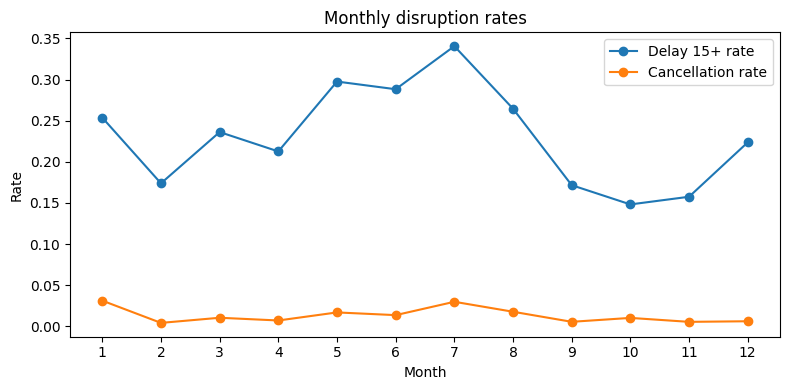

In [25]:
# Monthly disruption trends
monthly = (
    df.groupby("MONTH")
      .agg(
          flights=("MONTH", "size"),
          delay_rate=("TARGET_DELAY15", "mean"),
          cancel_rate=("TARGET_CANCELLED", "mean")
      )
      .reset_index()
      .sort_values("MONTH")
)

save_table(monthly, "monthly_disruption.csv", show=True)

plt.figure(figsize=(8, 4))
plt.plot(monthly["MONTH"], monthly["delay_rate"], marker="o", label="Delay 15+ rate")
plt.plot(monthly["MONTH"], monthly["cancel_rate"], marker="o", label="Cancellation rate")
plt.title("Monthly disruption rates")
plt.xlabel("Month")
plt.ylabel("Rate")
plt.xticks(monthly["MONTH"])
plt.legend()
save_fig("monthly_disruption_rates.png", show=True)


saved: capstone_outputs/tables/disruption_by_actual_departure_hour.csv


,ACTUAL_DEP_HOUR,flights,delay_rate,cancel_rate
0,0,16127,0.635828,0.003038
1,1,5289,0.784836,0.002836
2,2,1084,0.986162,0.003690
3,3,259,1.000000,0.000000
4,4,5676,0.034884,0.000000
5,5,49293,0.037308,0.000101
6,6,78865,0.057617,0.000152
7,7,119799,0.077196,0.000142
8,8,159135,0.089776,0.000339
9,9,144167,0.139986,0.000208


saved: capstone_outputs/figures/delay_by_actual_departure_hour.png


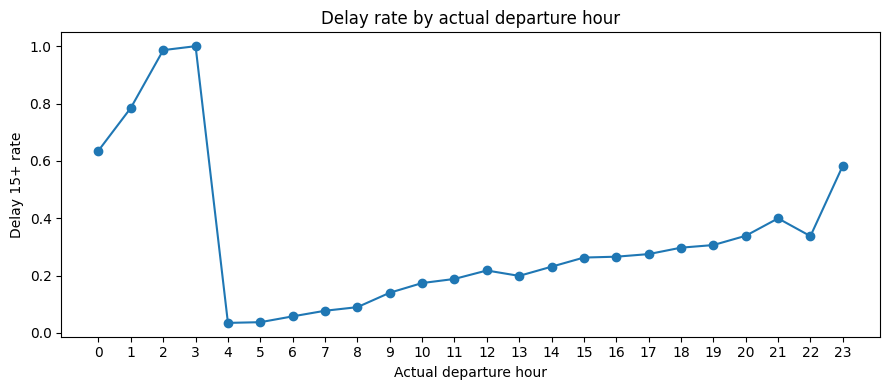


saved: capstone_outputs/tables/disruption_by_day_of_week.csv


,DAY_NAME,flights,delay_rate,cancel_rate
0,Monday,337157,0.232037,0.012324
1,Tuesday,308792,0.202434,0.011636
2,Wednesday,307707,0.203685,0.012177
3,Thursday,327089,0.236836,0.015809
4,Friday,330938,0.253867,0.015127
5,Saturday,295858,0.234965,0.012330
6,Sunday,330372,0.254774,0.013639


saved: capstone_outputs/figures/delay_by_day_of_week.png


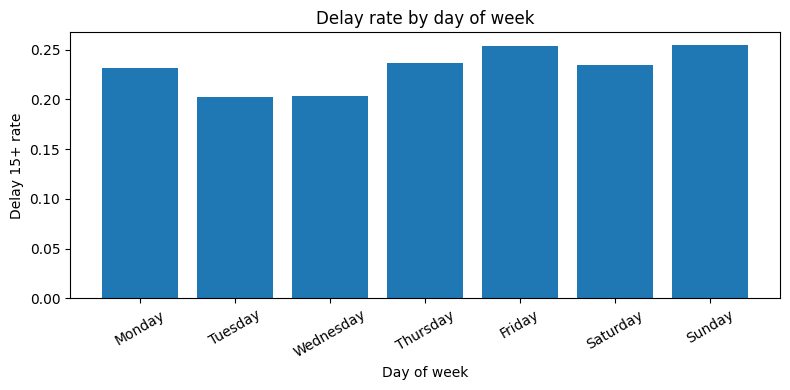

In [26]:
# Temporal patterns

if "DEP_TIME" in df.columns:
    dep_time_numeric = pd.to_numeric(df["DEP_TIME"], errors="coerce")
    df["ACTUAL_DEP_HOUR"] = ((dep_time_numeric // 100) % 24).astype("Int64")

    by_hour = (
        df.loc[df["ACTUAL_DEP_HOUR"].notna()]
          .groupby("ACTUAL_DEP_HOUR", observed=True)
          .agg(
              flights=("ACTUAL_DEP_HOUR", "size"),
              delay_rate=("TARGET_DELAY15", "mean"),
              cancel_rate=("TARGET_CANCELLED", "mean")
          )
          .reset_index()
          .sort_values("ACTUAL_DEP_HOUR")
    )

    save_table(by_hour, "disruption_by_actual_departure_hour.csv", show=True, max_rows=24)

    plt.figure(figsize=(9, 4))
    plt.plot(by_hour["ACTUAL_DEP_HOUR"], by_hour["delay_rate"], marker="o")
    plt.title("Delay rate by actual departure hour")
    plt.xlabel("Actual departure hour")
    plt.ylabel("Delay 15+ rate")
    plt.xticks(range(0, 24))
    save_fig("delay_by_actual_departure_hour.png", show=True)

dow = (
    df.assign(DAY_NAME=df["FLIGHT_DATE"].dt.day_name())
      .groupby("DAY_NAME", observed=True)
      .agg(
          flights=("ORIGIN", "size"),
          delay_rate=("TARGET_DELAY15", "mean"),
          cancel_rate=("TARGET_CANCELLED", "mean")
      )
      .reindex(["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"])
      .reset_index()
)

save_table(dow, "disruption_by_day_of_week.csv", show=True)

plt.figure(figsize=(8, 4))
plt.bar(dow["DAY_NAME"], dow["delay_rate"])
plt.title("Delay rate by day of week")
plt.xlabel("Day of week")
plt.ylabel("Delay 15+ rate")
plt.xticks(rotation=30)
save_fig("delay_by_day_of_week.png", show=True)


saved: capstone_outputs/tables/airport_disruption_summary.csv


,ORIGIN,flights,delay_rate,cancel_rate,avg_precip,avg_wind_gust
0,ATL,341910,0.197532,0.009973,3.901202,35.609742
3,DFW,313582,0.275268,0.018614,3.163220,37.262877
2,DEN,308645,0.231886,0.011291,1.020602,37.737418
9,ORD,280052,0.221815,0.013515,2.776616,39.633123
1,CLT,217574,0.264603,0.013683,3.154579,34.173747
6,LAX,194053,0.180403,0.008147,1.009273,38.565064
5,LAS,189252,0.235556,0.008824,0.280477,36.010763
7,MCO,159553,0.245677,0.018238,4.000754,35.183360
4,JFK,123348,0.202256,0.018590,3.130068,42.469779
8,MIA,109944,0.271532,0.017081,5.133541,37.119751


saved: capstone_outputs/figures/delay_rate_by_origin.png


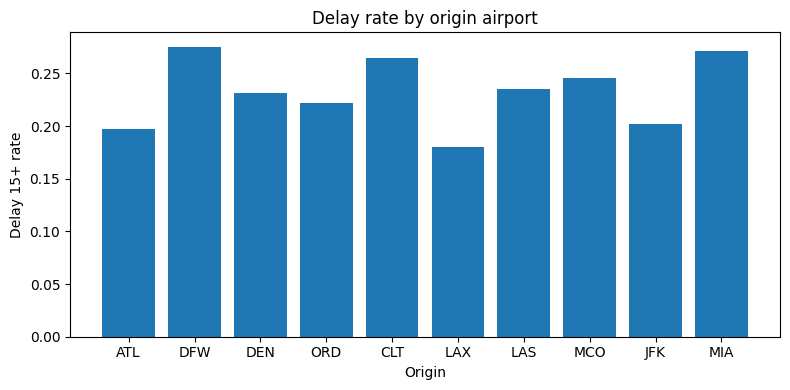

In [27]:
# Airport disruption summary
airport = (
    df.groupby("ORIGIN")
      .agg(
          flights=("ORIGIN", "size"),
          delay_rate=("TARGET_DELAY15", "mean"),
          cancel_rate=("TARGET_CANCELLED", "mean"),
          avg_precip=("W_PRECIPITATION_SUM", "mean") if "W_PRECIPITATION_SUM" in df.columns else ("ORIGIN", "size"),
          avg_wind_gust=("W_WIND_GUSTS_10M_MAX", "mean") if "W_WIND_GUSTS_10M_MAX" in df.columns else ("ORIGIN", "size")
      )
      .reset_index()
      .sort_values("flights", ascending=False)
)


save_table(airport, "airport_disruption_summary.csv", show=True)

plt.figure(figsize=(8, 4))
plt.bar(airport["ORIGIN"], airport["delay_rate"])
plt.title("Delay rate by origin airport")
plt.xlabel("Origin")
plt.ylabel("Delay 15+ rate")
save_fig("delay_rate_by_origin.png", show=True)


saved: capstone_outputs/tables/weather_delay_correlations.csv


,weather_feature,corr_with_delay
0,W_PRECIPITATION_SUM,0.099288
1,W_WIND_GUSTS_10M_MAX,0.052256
2,W_TEMPERATURE_2M_MEAN,0.053747
3,W_CLOUD_COVER_MEAN,0.064821



saved: capstone_outputs/tables/delay_by_precip_bin.csv


,PRECIP_BIN,flights,delay_rate,cancel_rate
0,none,1320373,0.197161,0.006453
1,light,455343,0.243155,0.011659
2,moderate,281097,0.298084,0.019947
3,heavy,181100,0.359594,0.057366


saved: capstone_outputs/figures/delay_by_precip_bin.png


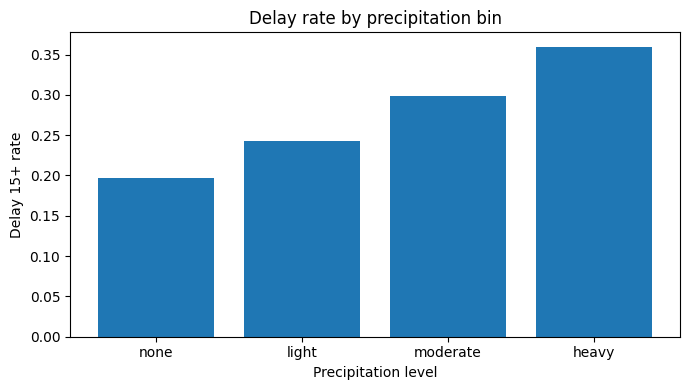


saved: capstone_outputs/tables/delay_by_wind_gust_bin.csv


,GUST_BIN,flights,delay_rate,cancel_rate
0,"(11.499, 28.8]",581531,0.209237,0.010601
1,"(28.8, 36.0]",544811,0.219059,0.009113
2,"(36.0, 43.9]",554564,0.242622,0.014271
3,"(43.9, 117.7]",557007,0.256938,0.019357


In [28]:
# Weather relationships
weather_delay = []
for c in ["W_PRECIPITATION_SUM", "W_WIND_GUSTS_10M_MAX", "W_TEMPERATURE_2M_MEAN", "W_CLOUD_COVER_MEAN"]:
    if c in df.columns:
        corr = df[[c, "TARGET_DELAY15"]].corr(numeric_only=True).iloc[0, 1]
        weather_delay.append([c, corr])

weather_delay = pd.DataFrame(weather_delay, columns=["weather_feature", "corr_with_delay"])
save_table(weather_delay, "weather_delay_correlations.csv", show=True)

if "W_PRECIPITATION_SUM" in df.columns:
    precip_bins = pd.cut(
        df["W_PRECIPITATION_SUM"],
        bins=[-0.01, 0, 2, 10, np.inf],
        labels=["none", "light", "moderate", "heavy"]
    )

    precip_delay = (
        df.assign(PRECIP_BIN=precip_bins)
          .groupby("PRECIP_BIN", observed=False)
          .agg(
              flights=("PRECIP_BIN", "size"),
              delay_rate=("TARGET_DELAY15", "mean"),
              cancel_rate=("TARGET_CANCELLED", "mean")
          )
          .reset_index()
    )

    save_table(precip_delay, "delay_by_precip_bin.csv", show=True)

    plt.figure(figsize=(7, 4))
    plt.bar(precip_delay["PRECIP_BIN"].astype(str), precip_delay["delay_rate"])
    plt.title("Delay rate by precipitation bin")
    plt.xlabel("Precipitation level")
    plt.ylabel("Delay 15+ rate")
    save_fig("delay_by_precip_bin.png", show=True)

if "W_WIND_GUSTS_10M_MAX" in df.columns:
    gust_bins = pd.qcut(df["W_WIND_GUSTS_10M_MAX"], q=4, duplicates="drop")
    gust_delay = (
        df.assign(GUST_BIN=gust_bins)
          .groupby("GUST_BIN", observed=False)
          .agg(
              flights=("GUST_BIN", "size"),
              delay_rate=("TARGET_DELAY15", "mean"),
              cancel_rate=("TARGET_CANCELLED", "mean")
          )
          .reset_index()
    )

    save_table(gust_delay, "delay_by_wind_gust_bin.csv", show=True)




saved: capstone_outputs/tables/top_routes_summary.csv


,ROUTE,flights,delay_rate,cancel_rate
959,LAX_SFO,11526,0.259081,0.009023
1243,ORD_LGA,10969,0.223915,0.020604
910,LAX_JFK,9915,0.170060,0.004438
689,JFK_LAX,9915,0.150359,0.003933
912,LAX_LAS,9603,0.233477,0.009060
791,LAS_LAX,9559,0.235610,0.007741
419,DEN_PHX,9446,0.241014,0.010692
978,MCO_ATL,8967,0.242500,0.015278
87,ATL_MCO,8935,0.261601,0.016228
762,LAS_DEN,8192,0.227767,0.012207


saved: capstone_outputs/figures/top_delay_routes.png


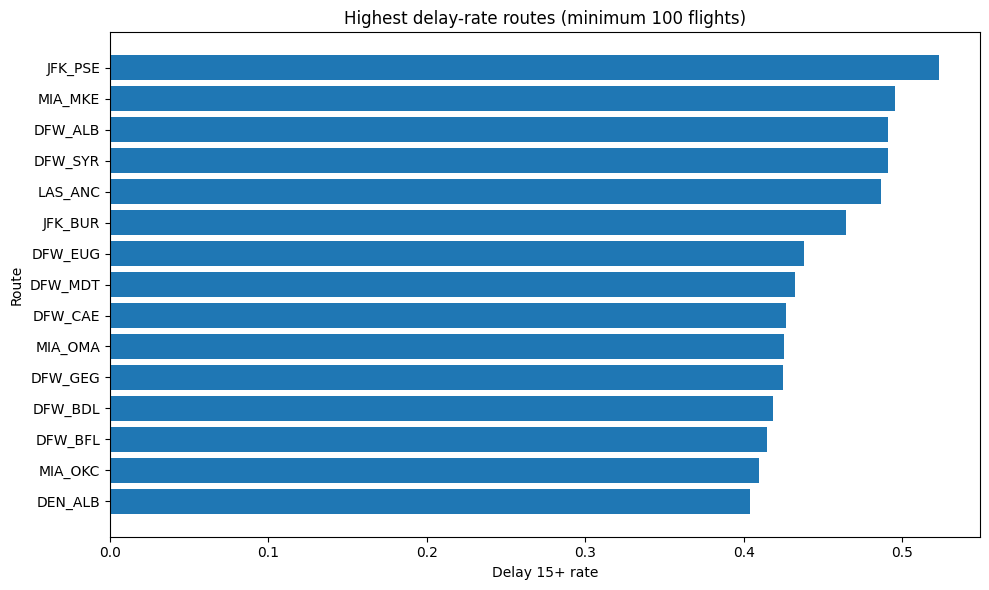


saved: capstone_outputs/tables/historical_feature_correlations.csv


,feature,corr_with_delay
4,carrier_route_carrier_route_delay_rate_roll14,0.205431
5,carrier_route_carrier_route_delay_rate_roll30,0.200083
2,route_route_delay_rate_roll14,0.177613
3,route_route_delay_rate_roll30,0.168462
7,CARRIER_ROUTE_DELAY_RATE_EXPANDING,0.158206
0,origin_origin_delay_rate_roll14,0.154124
8,TAIL_DELAY_RATE_ROLL30,0.140967
1,origin_origin_delay_rate_roll30,0.137420
9,PREV_PATTERN_DELAY_RATE_ROLL30,0.123294
6,ROUTE_DELAY_RATE_EXPANDING,0.117790


saved: capstone_outputs/figures/historical_feature_correlations.png


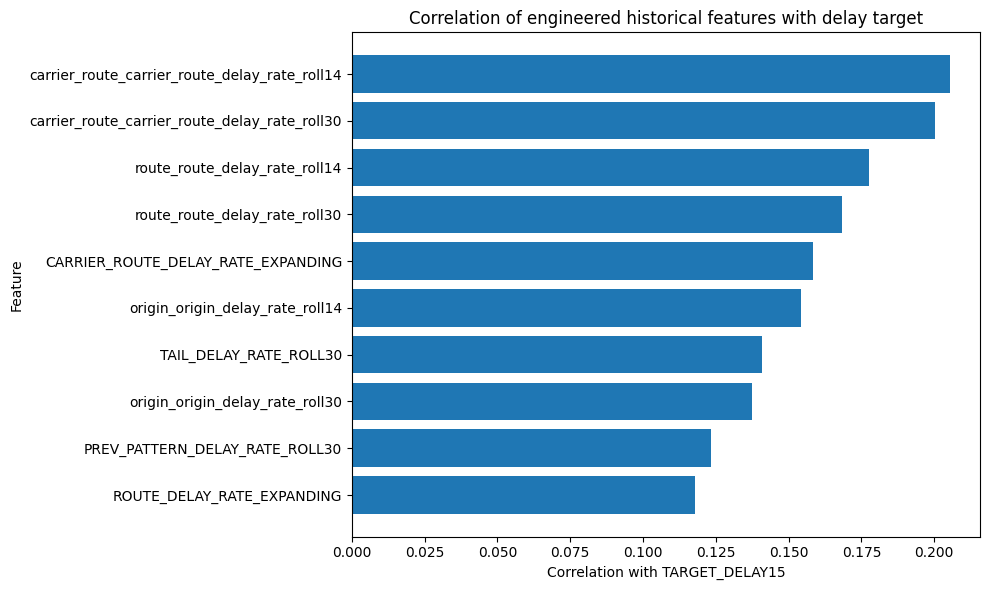

In [29]:
# Route concentration / historical patterns


top_routes = (
    df.groupby("ROUTE", observed=True)
      .agg(
          flights=("ROUTE", "size"),
          delay_rate=("TARGET_DELAY15", "mean"),
          cancel_rate=("TARGET_CANCELLED", "mean")
      )
      .reset_index()
      .sort_values("flights", ascending=False)
      .head(25)
)

save_table(top_routes, "top_routes_summary.csv", show=True, max_rows=25)

# Route delay figure: use meaningful-volume routes only, then show the 15 highest delay rates
route_plot = (
    df.groupby("ROUTE", observed=True)
      .agg(
          flights=("ROUTE", "size"),
          delay_rate=("TARGET_DELAY15", "mean")
      )
      .reset_index()
)

route_plot = route_plot[route_plot["flights"] >= 100].copy()
route_plot = route_plot.sort_values(["delay_rate", "flights"], ascending=[False, False]).head(15)

if not route_plot.empty:
    plt.figure(figsize=(10, 6))
    plt.barh(route_plot["ROUTE"], route_plot["delay_rate"])
    plt.gca().invert_yaxis()
    plt.title("Highest delay-rate routes (minimum 100 flights)")
    plt.xlabel("Delay 15+ rate")
    plt.ylabel("Route")
    save_fig("top_delay_routes.png", show=True)

hist_cols_for_review = [
    "origin_origin_delay_rate_roll14",
    "origin_origin_delay_rate_roll30",
    "route_route_delay_rate_roll14",
    "route_route_delay_rate_roll30",
    "carrier_route_carrier_route_delay_rate_roll14",
    "carrier_route_carrier_route_delay_rate_roll30",
    "ROUTE_DELAY_RATE_EXPANDING",
    "CARRIER_ROUTE_DELAY_RATE_EXPANDING",
    "TAIL_DELAY_RATE_ROLL30",
    "PREV_PATTERN_DELAY_RATE_ROLL30"
]
hist_cols_for_review = [c for c in hist_cols_for_review if c in df.columns]

hist_corr = []
for c in hist_cols_for_review:
    tmp = df[[c, "TARGET_DELAY15"]].dropna()
    if not tmp.empty:
        corr = tmp.corr(numeric_only=True).iloc[0, 1]
        hist_corr.append([c, corr])

hist_corr = (
    pd.DataFrame(hist_corr, columns=["feature", "corr_with_delay"])
      .sort_values("corr_with_delay", ascending=False)
)


save_table(hist_corr, "historical_feature_correlations.csv", show=True, max_rows=30)

if not hist_corr.empty:
    hist_corr_plot = hist_corr.sort_values("corr_with_delay", ascending=True)

    plt.figure(figsize=(10, 6))
    plt.barh(hist_corr_plot["feature"], hist_corr_plot["corr_with_delay"])
    plt.title("Correlation of engineered historical features with delay target")
    plt.xlabel("Correlation with TARGET_DELAY15")
    plt.ylabel("Feature")
    save_fig("historical_feature_correlations.png", show=True)

#### Output Model DF and Restart Session

In [46]:
MODEL_DF_PATH = OUT_DIR / "modeling_frame.parquet"
df.to_parquet(MODEL_DF_PATH, index=False)
print(MODEL_DF_PATH)

capstone_outputs/modeling_frame.parquet


In [48]:
# MODEL_DF_PATH = OUT_DIR / "modeling_frame_sample.csv"
# df[0:1000].to_csv(MODEL_DF_PATH, index=False)
# print(MODEL_DF_PATH)

# RESTART SESSION - Modeling

### Imports + Config

In [3]:
# ============================================================
# IMPORTS / CONFIG
# ============================================================

from pathlib import Path
import gc
import json
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

from sklearn.base import clone
from sklearn.dummy import DummyClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

RANDOM_STATE = 42

# -----------------------------
# PATHS
# -----------------------------
OUT_DIR = Path("capstone_outputs")
FIG_DIR = OUT_DIR / "figures"
TAB_DIR = OUT_DIR / "tables"
MODEL_DIR = OUT_DIR / "models"
CACHE_DIR = OUT_DIR / "cache"

for d in [OUT_DIR, FIG_DIR, TAB_DIR, MODEL_DIR, CACHE_DIR]:
    d.mkdir(parents=True, exist_ok=True)

MODEL_DF_PATH = OUT_DIR / "modeling_frame.parquet"

# -----------------------------
# TARGET / SPLIT CONFIG
# -----------------------------
TARGET_COL = "TARGET_DELAY15"
TARGET_LABEL = "Delay15Plus"

TRAIN_END = pd.Timestamp("2024-09-30")
TEST_START = pd.Timestamp("2024-10-01")

# -----------------------------
# SPEED / MEMORY CONTROLS
# -----------------------------
# cap training rows per CV fold
MAX_TRAIN_ROWS_PER_FOLD = 350_000

# cap for final model fit to prioritize recency + speed
MAX_FINAL_TRAIN_ROWS = 500_000

# expanding CV setup
CV_MIN_TRAIN_DAYS = 140
CV_VAL_DAYS = 28
CV_STEP_DAYS = 42
CV_MAX_FOLDS = 3

# target encoding settings
TE_SMOOTHING = 30.0
TE_MIN_SAMPLES = 50

# feature selection settings
HIGH_MISSING_DROP_THRESHOLD = 0.70
LOW_CARD_THRESHOLD = 20

USE_PCA_FOR_LOGREG = False

# -----------------------------
# OUTPUT HELPERS
# -----------------------------
def save_table(df, name, show=True, max_rows=20):
    path = TAB_DIR / name
    df.to_csv(path, index=False)
    print(f"\nsaved: {path}")

    if show:
        if len(df) <= max_rows:
            display(df)
        else:
            display(df.head(max_rows))
            print(f"[showing first {max_rows} of {len(df)} rows]")

def save_fig(name, show=True):
    path = FIG_DIR / name
    plt.tight_layout()
    plt.savefig(path, dpi=170, bbox_inches="tight")
    print(f"saved: {path}")
    if show:
        plt.show()
    else:
        plt.close()

def mem_mb(df):
    return round(df.memory_usage(deep=True).sum() / (1024 ** 2), 2)

def downcast_numeric(df):
    out = df.copy()
    for c in out.select_dtypes(include=["float64"]).columns:
        out[c] = out[c].astype("float32")
    for c in out.select_dtypes(include=["int64"]).columns:
        out[c] = pd.to_numeric(out[c], downcast="integer")
    return out

def replace_pandas_na(df):
    return df.replace({pd.NA: np.nan})

### Helper Functions for Modeling

In [6]:
# ============================================================
# MODELING HELPERS
# ============================================================

def make_expanding_date_folds(
    date_series,
    min_train_days=140,
    val_days=28,
    step_days=42,
    max_folds=3
):
    """
    Expanding-window folds using unique calendar dates.
    Returns list of tuples:
    (train_idx, val_idx, train_end_date, val_start_date, val_end_date)
    """
    dates = pd.to_datetime(date_series).dt.normalize()
    unique_dates = pd.Series(sorted(dates.dropna().unique()))

    folds = []
    start_i = min_train_days

    while start_i + val_days <= len(unique_dates):
        train_end = unique_dates.iloc[start_i - 1]
        val_start = unique_dates.iloc[start_i]
        val_end = unique_dates.iloc[start_i + val_days - 1]

        train_idx = dates[dates <= train_end].index.to_numpy()
        val_idx = dates[(dates >= val_start) & (dates <= val_end)].index.to_numpy()

        folds.append((train_idx, val_idx, train_end, val_start, val_end))

        if len(folds) >= max_folds:
            break

        start_i += step_days

    return folds

def cap_recent_rows(df, max_rows=None):
    if max_rows is None or len(df) <= max_rows:
        return df.copy()
    return df.sort_values("FLIGHT_DATE").tail(max_rows).copy()

def fit_target_encoding_maps(X, y, cols, smoothing=30.0, min_samples=50):
    global_mean = float(np.mean(y))
    te_maps = {}

    for col in cols:
        tmp = pd.DataFrame({
            "key": X[col].astype("object").fillna("__MISSING__"),
            "y": y.astype("float32")
        })

        stats = tmp.groupby("key", observed=False)["y"].agg(["count", "mean"])
        stats["count"] = stats["count"].astype("float32")
        stats["mean"] = stats["mean"].astype("float32")

        # smoothed mean encoding
        smooth = (stats["count"] * stats["mean"] + smoothing * global_mean) / (stats["count"] + smoothing)

        # stronger shrinkage for very rare categories
        smooth.loc[stats["count"] < min_samples] = (
            (stats.loc[stats["count"] < min_samples, "count"] * stats.loc[stats["count"] < min_samples, "mean"] + smoothing * global_mean)
            / (stats.loc[stats["count"] < min_samples, "count"] + smoothing)
        )

        te_maps[col] = smooth.to_dict()

    return te_maps, global_mean

def apply_target_encoding(X, cols, te_maps, global_mean):
    out = pd.DataFrame(index=X.index)

    for col in cols:
        key = X[col].astype("object").fillna("__MISSING__")
        out[f"TE_{col}"] = key.map(te_maps[col]).fillna(global_mean).astype("float32")

    return out

def fit_frequency_maps(X, cols):
    freq_maps = {}
    n = len(X)

    for col in cols:
        vc = X[col].astype("object").fillna("__MISSING__").value_counts(dropna=False)
        freq_maps[col] = (vc / n).to_dict()

    return freq_maps

def apply_frequency_encoding(X, cols, freq_maps):
    out = pd.DataFrame(index=X.index)

    for col in cols:
        key = X[col].astype("object").fillna("__MISSING__")
        out[f"FREQ_{col}"] = key.map(freq_maps[col]).fillna(0.0).astype("float32")

    return out

def build_model_matrix(
    X_fit,
    y_fit,
    X_apply,
    numeric_cols,
    low_card_cols,
    high_card_te_cols,
    freq_cols,
    te_smoothing=30.0,
    te_min_samples=50
):
    """
    Build a compact, dense numeric design matrix.
    - numeric cols: median imputed later in model pipeline
    - low-card categoricals: one-hot
    - selected high-card categoricals: target-encoded
    - very sparse IDs: frequency-encoded
    """

    # numeric block
    X_fit_num = X_fit[numeric_cols].copy()
    X_apply_num = X_apply[numeric_cols].copy()

    for c in X_fit_num.columns:
        X_fit_num[c] = pd.to_numeric(X_fit_num[c], errors="coerce").astype("float32")
        X_apply_num[c] = pd.to_numeric(X_apply_num[c], errors="coerce").astype("float32")

    # low-cardinality one-hot
    X_fit_low = pd.DataFrame(index=X_fit.index)
    X_apply_low = pd.DataFrame(index=X_apply.index)

    if low_card_cols:
        fit_low = X_fit[low_card_cols].copy()
        apply_low = X_apply[low_card_cols].copy()

        for c in low_card_cols:
            fit_low[c] = fit_low[c].astype("object").fillna("__MISSING__")
            apply_low[c] = apply_low[c].astype("object").fillna("__MISSING__")

        X_fit_low = pd.get_dummies(fit_low, drop_first=False, dtype="uint8")
        X_apply_low = pd.get_dummies(apply_low, drop_first=False, dtype="uint8")
        X_fit_low, X_apply_low = X_fit_low.align(X_apply_low, join="left", axis=1, fill_value=0)

    # target encoding for selected high-cardinality categoricals
    X_fit_te = pd.DataFrame(index=X_fit.index)
    X_apply_te = pd.DataFrame(index=X_apply.index)

    if high_card_te_cols:
        te_maps, global_mean = fit_target_encoding_maps(
            X_fit,
            y_fit,
            high_card_te_cols,
            smoothing=te_smoothing,
            min_samples=te_min_samples
        )
        X_fit_te = apply_target_encoding(X_fit, high_card_te_cols, te_maps, global_mean)
        X_apply_te = apply_target_encoding(X_apply, high_card_te_cols, te_maps, global_mean)

    # frequency encoding for ultra-sparse identifiers
    X_fit_freq = pd.DataFrame(index=X_fit.index)
    X_apply_freq = pd.DataFrame(index=X_apply.index)

    if freq_cols:
        freq_maps = fit_frequency_maps(X_fit, freq_cols)
        X_fit_freq = apply_frequency_encoding(X_fit, freq_cols, freq_maps)
        X_apply_freq = apply_frequency_encoding(X_apply, freq_cols, freq_maps)

    X_fit_final = pd.concat([X_fit_num, X_fit_low, X_fit_te, X_fit_freq], axis=1)
    X_apply_final = pd.concat([X_apply_num, X_apply_low, X_apply_te, X_apply_freq], axis=1)

    # final numeric coercion
    for c in X_fit_final.columns:
        X_fit_final[c] = pd.to_numeric(X_fit_final[c], errors="coerce").astype("float32")
        X_apply_final[c] = pd.to_numeric(X_apply_final[c], errors="coerce").astype("float32")

    return X_fit_final, X_apply_final

def get_model_pipeline(model_name):
    if model_name == "DummyPrior":
        return DummyClassifier(strategy="prior")

    if model_name == "LogisticRegression":
        return Pipeline([
            ("imp", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(
                solver="lbfgs",
                max_iter=300,
                C=0.5,
                class_weight=None,
                random_state=RANDOM_STATE
            ))
        ])

    if model_name == "RandomForest":
        return Pipeline([
            ("imp", SimpleImputer(strategy="median")),
            ("model", RandomForestClassifier(
                n_estimators=120,
                max_depth=12,
                min_samples_leaf=40,
                max_features="sqrt",
                class_weight=None,
                n_jobs=-1,
                random_state=RANDOM_STATE
            ))
        ])

    if model_name == "HistGB":
        return Pipeline([
            ("imp", SimpleImputer(strategy="median")),
            ("model", HistGradientBoostingClassifier(
                learning_rate=0.05,
                max_iter=160,
                max_depth=6,
                min_samples_leaf=60,
                l2_regularization=1.0,
                random_state=RANDOM_STATE
            ))
        ])

    raise ValueError(f"Unknown model: {model_name}")

def predict_proba_from_pipeline(pipe, X):
    if hasattr(pipe, "predict_proba"):
        return pipe.predict_proba(X)[:, 1]
    if hasattr(pipe, "decision_function"):
        return pipe.decision_function(X)
    raise ValueError("Model does not expose predict_proba or decision_function")

def threshold_summary(y_true, pred_prob):
    precision, recall, thresholds = precision_recall_curve(y_true, pred_prob)

    if len(thresholds) == 0:
        return 0.5, pd.DataFrame(columns=["threshold", "precision", "recall", "f1"])

    f1 = 2 * precision[:-1] * recall[:-1] / np.clip(precision[:-1] + recall[:-1], 1e-9, None)

    diag = pd.DataFrame({
        "threshold": thresholds,
        "precision": precision[:-1],
        "recall": recall[:-1],
        "f1": f1
    }).sort_values("f1", ascending=False)

    best_threshold = float(diag.iloc[0]["threshold"])
    return best_threshold, diag

def metric_row(y_true, pred_prob, threshold, split_name, model_name):
    pred = (pred_prob >= threshold).astype("int8")

    return {
        "model": model_name,
        "split": split_name,
        "threshold": round(float(threshold), 4),
        "accuracy": round(float(accuracy_score(y_true, pred)), 4),
        "balanced_accuracy": round(float(balanced_accuracy_score(y_true, pred)), 4),
        "precision": round(float(precision_score(y_true, pred, zero_division=0)), 4),
        "recall": round(float(recall_score(y_true, pred, zero_division=0)), 4),
        "f1": round(float(f1_score(y_true, pred, zero_division=0)), 4),
        "roc_auc": round(float(roc_auc_score(y_true, pred_prob)), 4),
        "pr_auc": round(float(average_precision_score(y_true, pred_prob)), 4),
        "predicted_positive_rate": round(float(np.mean(pred)), 4),
        "actual_positive_rate": round(float(np.mean(y_true)), 4),
    }

def style_metric_table(df, metric_cols):
    styled = (
        df.style
        .highlight_max(subset=metric_cols, color="lightgreen")
        .highlight_min(subset=metric_cols, color="#f4cccc")
        .format(precision=4)
    )
    return styled

### Final Data Preparation

In [11]:
# ============================================================
# LOAD MODELING FRAME + FINAL GLOBAL PREP
# ============================================================

df = pd.read_parquet(MODEL_DF_PATH)
print("raw shape:", df.shape)
print("raw memory MB:", mem_mb(df))

df["FLIGHT_DATE"] = pd.to_datetime(df["FLIGHT_DATE"], errors="coerce")
df = df.loc[df["FLIGHT_DATE"].notna()].sort_values("FLIGHT_DATE").reset_index(drop=True)

# -----------------------------
# target cleanup
# -----------------------------
df[TARGET_COL] = pd.to_numeric(df[TARGET_COL], errors="coerce")
df["TARGET_CANCELLED"] = pd.to_numeric(df["TARGET_CANCELLED"], errors="coerce")

# -----------------------------
# compact seasonality features
# -----------------------------
if "DAY_OF_YEAR" not in df.columns:
    df["DAY_OF_YEAR"] = df["FLIGHT_DATE"].dt.dayofyear.astype("int16")

df["DOY_SIN"] = np.sin(2 * np.pi * df["DAY_OF_YEAR"] / 366).astype("float32")
df["DOY_COS"] = np.cos(2 * np.pi * df["DAY_OF_YEAR"] / 366).astype("float32")

# -----------------------------
# make selected categoricals explicit
# -----------------------------
for c in ["ORIGIN", "DEST", "ROUTE", "CARRIER_ROUTE", "TAIL_NUM", "OP_CARRIER_AIRLINE_ID"]:
    if c in df.columns:
        df[c] = df[c].astype("object")

# -----------------------------
# leakage / unsafe / low-value drops
# -----------------------------
LEAKAGE_AND_POST_EVENT_COLS = [
    "DEP_TIME", "DEP_DELAY", "DEP_DEL15", "CANCELLED",
    "TAXI_OUT", "TAXI_IN", "ARR_TIME", "ARR_DELAY", "ARR_DEL15",
    "ACTUAL_ELAPSED_TIME", "AIR_TIME",
    "CARRIER_DELAY", "WEATHER_DELAY", "NAS_DELAY",
    "SECURITY_DELAY", "LATE_AIRCRAFT_DELAY",
    "ACTUAL_DEP_HOUR"
]

# global manual pruning:
# - remove duplicate IDs / labels
# - remove extremely sparse pattern fields
# - remove clearly redundant calendar fields after DOY_SIN / DOY_COS
# - keep only the more useful rolling windows (lag1 + roll30)
MANUAL_DROP_COLS = [
    "YEAR",
    "QUARTER",
    "DAY_OF_MONTH",
    "DAY_OF_YEAR",          # replaced by DOY_SIN / DOY_COS
    "ORIGIN_AIRPORT_ID",
    "DEST_AIRPORT_ID",
    "ORIGIN_CITY_NAME",
    "DEST_CITY_NAME",
    "DISTANCE",             # use LOG_DISTANCE instead
    "PREV_ORIGIN_DEST",
    "PREV_PATTERN_DELAY_RATE_ROLL30",
    "PREV_PATTERN_CANCEL_RATE_ROLL30",
    "W_TEMPERATURE_2M_MAX",
    "W_TEMPERATURE_2M_MIN",
    "W_RAIN_SUM",
    "W_WIND_SPEED_10M_MAX",
]

# drop highly missing columns globally
high_missing_cols = [c for c in df.columns if df[c].isna().mean() > HIGH_MISSING_DROP_THRESHOLD]

# drop redundant rolling windows: keep lag1 + roll30, remove roll14 + roll60
redundant_roll_cols = [
    c for c in df.columns
    if (
        c.endswith("_roll14") or c.endswith("_roll60")
    )
]

# combine all drops
DROP_COLS = sorted(set(
    [c for c in LEAKAGE_AND_POST_EVENT_COLS if c in df.columns] +
    [c for c in MANUAL_DROP_COLS if c in df.columns] +
    high_missing_cols +
    redundant_roll_cols
))

# never drop essential columns
ESSENTIAL_COLS = {"FLIGHT_DATE", TARGET_COL, "TARGET_CANCELLED", "ORIGIN", "DEST", "ROUTE", "CARRIER_ROUTE", "TAIL_NUM", "OP_CARRIER_AIRLINE_ID", "DOY_SIN", "DOY_COS", "LOG_DISTANCE", "IS_WEEKEND"}
DROP_COLS = [c for c in DROP_COLS if c not in ESSENTIAL_COLS]

df = df.drop(columns=DROP_COLS, errors="ignore")

# remove constant columns
constant_cols = [c for c in df.columns if df[c].nunique(dropna=False) <= 1]
constant_cols = [c for c in constant_cols if c not in [TARGET_COL, "TARGET_CANCELLED", "FLIGHT_DATE"]]
df = df.drop(columns=constant_cols, errors="ignore")

df = replace_pandas_na(df)
df = downcast_numeric(df)

print("reduced shape:", df.shape)
print("reduced memory MB:", mem_mb(df))
print("\nDropped columns:", len(DROP_COLS) + len(constant_cols))

feature_manifest = pd.DataFrame({
    "column": df.columns,
    "dtype": df.dtypes.astype(str),
    "missing_pct": df.isna().mean() * 100,
    "nunique": [df[c].nunique(dropna=False) for c in df.columns]
}).sort_values(["dtype", "column"])

save_table(feature_manifest, f"{TARGET_LABEL.lower()}_feature_manifest_reduced.csv", show=True, max_rows=40)

REDUCED_MODEL_DF_PATH = OUT_DIR / f"{TARGET_LABEL.lower()}_modeling_frame_reduced.parquet"
df.to_parquet(REDUCED_MODEL_DF_PATH, index=False)
print("\nSaved reduced modeling frame to:", REDUCED_MODEL_DF_PATH)

raw shape: (2237913, 117)
raw memory MB: 2207.0
reduced shape: (2237913, 68)
reduced memory MB: 1141.63

Dropped columns: 51

saved: capstone_outputs/tables/delay15plus_feature_manifest_reduced.csv


,column,dtype,missing_pct,nunique
FLIGHT_DATE,FLIGHT_DATE,datetime64[ns],0.000000,366
CARRIER_ROUTE_CANCEL_RATE_EXPANDING,CARRIER_ROUTE_CANCEL_RATE_EXPANDING,float32,1.368418,132684
CARRIER_ROUTE_DELAY_RATE_EXPANDING,CARRIER_ROUTE_DELAY_RATE_EXPANDING,float32,1.387453,394263
DOY_COS,DOY_COS,float32,0.000000,184
DOY_SIN,DOY_SIN,float32,0.000000,184
LOG_DISTANCE,LOG_DISTANCE,float32,0.000000,945
OP_CARRIER_FL_NUM,OP_CARRIER_FL_NUM,float32,0.000045,6470
ROUTE_CANCEL_RATE_EXPANDING,ROUTE_CANCEL_RATE_EXPANDING,float32,0.579156,278898
ROUTE_DELAY_RATE_EXPANDING,ROUTE_DELAY_RATE_EXPANDING,float32,0.583892,664262
TAIL_CANCEL_RATE_ROLL30,TAIL_CANCEL_RATE_ROLL30,float32,2.591611,1487


[showing first 40 of 68 rows]

Saved reduced modeling frame to: capstone_outputs/delay15plus_modeling_frame_reduced.parquet


In [12]:
#df.head()

In [13]:
# for col in df.columns:
#   print(col)

### Data Splitting & Feature Encoding

In [16]:
# ============================================================
# SPLIT DATA + DEFINE FEATURE ROLES
# ============================================================

df = pd.read_parquet(REDUCED_MODEL_DF_PATH)
df["FLIGHT_DATE"] = pd.to_datetime(df["FLIGHT_DATE"], errors="coerce")
df = df.sort_values("FLIGHT_DATE").reset_index(drop=True)

train_df = df.loc[df["FLIGHT_DATE"] <= TRAIN_END].copy()
test_df = df.loc[df["FLIGHT_DATE"] >= TEST_START].copy()

# remove missing target rows
train_df = train_df.loc[train_df[TARGET_COL].notna()].copy()
test_df = test_df.loc[test_df[TARGET_COL].notna()].copy()

print("train shape:", train_df.shape)
print("test shape :", test_df.shape)
print("train positive rate:", round(float(train_df[TARGET_COL].mean()), 4))
print("test positive rate :", round(float(test_df[TARGET_COL].mean()), 4))

# keep metadata for business-facing evaluation outputs
meta_cols = [c for c in ["FLIGHT_DATE", "ORIGIN", "DEST", "ROUTE", "CARRIER_ROUTE"] if c in train_df.columns]

# predictor drop list
base_drop_cols = ["FLIGHT_DATE", TARGET_COL, "TARGET_CANCELLED"]

X_train_base = train_df.drop(columns=[c for c in base_drop_cols if c in train_df.columns], errors="ignore").copy()
y_train = train_df[TARGET_COL].astype("int8").copy()

X_test_base = test_df.drop(columns=[c for c in base_drop_cols if c in test_df.columns], errors="ignore").copy()
y_test = test_df[TARGET_COL].astype("int8").copy()

meta_train = train_df[meta_cols].copy()
meta_test = test_df[meta_cols].copy()

# define feature role buckets
all_cat_cols = X_train_base.select_dtypes(include=["object", "category", "string"]).columns.tolist()
all_num_cols = [c for c in X_train_base.columns if c not in all_cat_cols]

# explicit encoding strategy
low_card_cols = [c for c in all_cat_cols if X_train_base[c].nunique(dropna=False) <= LOW_CARD_THRESHOLD]
high_card_te_cols = [c for c in ["DEST", "ROUTE", "CARRIER_ROUTE"] if c in all_cat_cols]
freq_cols = [c for c in ["TAIL_NUM"] if c in all_cat_cols]

# remove selected high-card/freq cols from low_card bucket
low_card_cols = [c for c in low_card_cols if c not in high_card_te_cols + freq_cols]

# drop any remaining categoricals not explicitly assigned
assigned_cat = set(low_card_cols + high_card_te_cols + freq_cols)
other_cat_cols = [c for c in all_cat_cols if c not in assigned_cat]

if other_cat_cols:
    print("\nDropping unassigned categoricals:", other_cat_cols)
    X_train_base = X_train_base.drop(columns=other_cat_cols, errors="ignore")
    X_test_base = X_test_base.drop(columns=other_cat_cols, errors="ignore")

all_num_cols = [c for c in X_train_base.columns if c not in low_card_cols + high_card_te_cols + freq_cols]

print("\nFeature role summary")
print("numeric:", len(all_num_cols))
print("low-card one-hot:", low_card_cols)
print("target-encoded:", high_card_te_cols)
print("frequency-encoded:", freq_cols)

role_df = pd.DataFrame({
    "feature": X_train_base.columns,
    "role": [
        "numeric" if c in all_num_cols else
        "low_card_ohe" if c in low_card_cols else
        "target_encoded" if c in high_card_te_cols else
        "frequency_encoded" if c in freq_cols else
        "dropped"
        for c in X_train_base.columns
    ]
}).sort_values(["role", "feature"])

save_table(role_df, f"{TARGET_LABEL.lower()}_feature_roles_modeling.csv", show=True, max_rows=100)

train shape: (1649526, 68)
test shape : (559727, 68)
train positive rate: 0.2505
test positive rate : 0.1763

Feature role summary
numeric: 60
low-card one-hot: ['ORIGIN']
target-encoded: ['DEST', 'ROUTE', 'CARRIER_ROUTE']
frequency-encoded: ['TAIL_NUM']

saved: capstone_outputs/tables/delay15plus_feature_roles_modeling.csv


,feature,role
2,TAIL_NUM,frequency_encoded
4,ORIGIN,low_card_ohe
54,CARRIER_ROUTE_CANCEL_RATE_EXPANDING,numeric
53,CARRIER_ROUTE_DELAY_RATE_EXPANDING,numeric
52,CARRIER_ROUTE_OBS_BEFORE,numeric
...,...,...
39,route_route_delay_rate_lag1,numeric
40,route_route_delay_rate_roll30,numeric
8,CARRIER_ROUTE,target_encoded
5,DEST,target_encoded


### Build CV folds framework

In [19]:
# ============================================================
# EXPANDING WINDOW CV FOLDS
# ============================================================

cv_folds = make_expanding_date_folds(
    date_series=meta_train["FLIGHT_DATE"],
    min_train_days=CV_MIN_TRAIN_DAYS,
    val_days=CV_VAL_DAYS,
    step_days=CV_STEP_DAYS,
    max_folds=CV_MAX_FOLDS
)

fold_summary = pd.DataFrame([
    {
        "fold": i + 1,
        "train_end": tr_end.date(),
        "val_start": va_start.date(),
        "val_end": va_end.date(),
        "train_rows_before_cap": len(tr_idx),
        "val_rows": len(va_idx),
        "train_pos_rate": round(float(y_train.iloc[tr_idx].mean()), 4),
        "val_pos_rate": round(float(y_train.iloc[va_idx].mean()), 4),
    }
    for i, (tr_idx, va_idx, tr_end, va_start, va_end) in enumerate(cv_folds)
])

save_table(fold_summary, f"{TARGET_LABEL.lower()}_cv_folds.csv", show=True)


saved: capstone_outputs/tables/delay15plus_cv_folds.csv


,fold,train_end,val_start,val_end,train_rows_before_cap,val_rows,train_pos_rate,val_pos_rate
0,1,2024-05-19,2024-05-20,2024-06-16,819682,174413,0.2294,0.2875
1,2,2024-06-30,2024-07-01,2024-07-28,1083001,172905,0.2444,0.3473
2,3,2024-08-11,2024-08-12,2024-09-08,1342952,171018,0.2616,0.1965


### Cross Validation & Threshold Optimization

In [22]:
# ============================================================
# CROSS-VALIDATION
# ============================================================

MODEL_NAMES = ["DummyPrior", "LogisticRegression", "RandomForest", "HistGB"]

cv_rows = []
oof_predictions = {}

for model_name in MODEL_NAMES:
    print(f"\n==============================")
    print(f"CV MODEL: {model_name}")
    print(f"==============================")

    oof_prob = pd.Series(index=X_train_base.index, dtype="float32")

    for fold_i, (tr_idx, va_idx, tr_end, va_start, va_end) in enumerate(cv_folds, start=1):
        print(f"\nFold {fold_i}: train_end={tr_end.date()} val={va_start.date()} to {va_end.date()}")

        X_tr = X_train_base.iloc[tr_idx].copy()
        y_tr = y_train.iloc[tr_idx].copy()
        X_va = X_train_base.iloc[va_idx].copy()
        y_va = y_train.iloc[va_idx].copy()

        # recency cap to keep runtime under control and improve temporal relevance
        tr_fold = pd.concat([meta_train.iloc[tr_idx][["FLIGHT_DATE"]], X_tr, y_tr.rename(TARGET_COL)], axis=1)
        tr_fold = cap_recent_rows(tr_fold, MAX_TRAIN_ROWS_PER_FOLD)

        y_tr = tr_fold[TARGET_COL].astype("int8").copy()
        X_tr = tr_fold.drop(columns=["FLIGHT_DATE", TARGET_COL], errors="ignore").copy()

        # fold-safe matrix build
        X_tr_final, X_va_final = build_model_matrix(
            X_fit=X_tr,
            y_fit=y_tr,
            X_apply=X_va,
            numeric_cols=all_num_cols,
            low_card_cols=low_card_cols,
            high_card_te_cols=high_card_te_cols,
            freq_cols=freq_cols,
            te_smoothing=TE_SMOOTHING,
            te_min_samples=TE_MIN_SAMPLES
        )

        print("  train matrix:", X_tr_final.shape, "val matrix:", X_va_final.shape)

        model = get_model_pipeline(model_name)

        t0 = time.time()
        model.fit(X_tr_final, y_tr)
        fit_sec = time.time() - t0

        if model_name == "DummyPrior":
            prob_va = model.predict_proba(X_va_final)[:, 1]
        else:
            prob_va = predict_proba_from_pipeline(model, X_va_final)

        oof_prob.iloc[va_idx] = prob_va.astype("float32")

        fold_row = {
            "model": model_name,
            "fold": fold_i,
            "fit_sec": round(float(fit_sec), 2),
            "train_rows_after_cap": len(X_tr_final),
            "val_rows": len(X_va_final),
            "val_roc_auc": round(float(roc_auc_score(y_va, prob_va)), 4),
            "val_pr_auc": round(float(average_precision_score(y_va, prob_va)), 4),
        }
        cv_rows.append(fold_row)
        print(" ", fold_row)

        del X_tr, y_tr, X_va, y_va, X_tr_final, X_va_final, model, tr_fold, prob_va
        gc.collect()

    valid_mask = oof_prob.notna()
    oof_y = y_train.loc[valid_mask].astype("int8")
    oof_p = oof_prob.loc[valid_mask].astype("float32")

    best_threshold, threshold_diag = threshold_summary(oof_y, oof_p)
    threshold_diag_path = f"{TARGET_LABEL.lower()}_{model_name.lower()}_oof_thresholds.csv"
    save_table(threshold_diag.head(50), threshold_diag_path, show=True, max_rows=20)

    oof_row = {
        "model": model_name,
        "fold": "OOF_COMBINED",
        "fit_sec": np.nan,
        "train_rows_after_cap": np.nan,
        "val_rows": int(valid_mask.sum()),
        "val_roc_auc": round(float(roc_auc_score(oof_y, oof_p)), 4),
        "val_pr_auc": round(float(average_precision_score(oof_y, oof_p)), 4),
        "best_f1_threshold": round(float(best_threshold), 4),
        "oof_precision_at_best_f1": round(float(precision_score(oof_y, (oof_p >= best_threshold).astype(int), zero_division=0)), 4),
        "oof_recall_at_best_f1": round(float(recall_score(oof_y, (oof_p >= best_threshold).astype(int), zero_division=0)), 4),
        "oof_f1_at_best_f1": round(float(f1_score(oof_y, (oof_p >= best_threshold).astype(int), zero_division=0)), 4),
    }
    cv_rows.append(oof_row)
    oof_predictions[model_name] = {"y": oof_y.copy(), "prob": oof_p.copy(), "threshold": best_threshold}

    del oof_prob, oof_y, oof_p, threshold_diag
    gc.collect()

cv_results = pd.DataFrame(cv_rows)
save_table(cv_results, f"{TARGET_LABEL.lower()}_cv_results.csv", show=True, max_rows=50)

cv_summary = (
    cv_results[cv_results["fold"] != "OOF_COMBINED"]
    .groupby("model", as_index=False)
    .agg(
        mean_fit_sec=("fit_sec", "mean"),
        mean_val_roc_auc=("val_roc_auc", "mean"),
        mean_val_pr_auc=("val_pr_auc", "mean"),
    )
)

oof_summary = cv_results[cv_results["fold"] == "OOF_COMBINED"][
    ["model", "best_f1_threshold", "oof_precision_at_best_f1", "oof_recall_at_best_f1", "oof_f1_at_best_f1", "val_roc_auc", "val_pr_auc"]
].rename(columns={"val_roc_auc": "oof_roc_auc", "val_pr_auc": "oof_pr_auc"})

cv_model_summary = cv_summary.merge(oof_summary, on="model", how="left").sort_values("mean_val_pr_auc", ascending=False)
save_table(cv_model_summary, f"{TARGET_LABEL.lower()}_cv_model_summary.csv", show=True)

display(style_metric_table(
    cv_model_summary,
    metric_cols=["mean_val_roc_auc", "mean_val_pr_auc", "oof_roc_auc", "oof_pr_auc", "oof_f1_at_best_f1"]
))

best_model_name = cv_model_summary.iloc[0]["model"]
print("\nBest model by mean CV PR-AUC:", best_model_name)


CV MODEL: DummyPrior

Fold 1: train_end=2024-05-19 val=2024-05-20 to 2024-06-16
  train matrix: (350000, 74) val matrix: (174413, 74)
  {'model': 'DummyPrior', 'fold': 1, 'fit_sec': 0.01, 'train_rows_after_cap': 350000, 'val_rows': 174413, 'val_roc_auc': 0.5, 'val_pr_auc': 0.2875}

Fold 2: train_end=2024-06-30 val=2024-07-01 to 2024-07-28
  train matrix: (350000, 74) val matrix: (172905, 74)
  {'model': 'DummyPrior', 'fold': 2, 'fit_sec': 0.01, 'train_rows_after_cap': 350000, 'val_rows': 172905, 'val_roc_auc': 0.5, 'val_pr_auc': 0.3473}

Fold 3: train_end=2024-08-11 val=2024-08-12 to 2024-09-08
  train matrix: (350000, 74) val matrix: (171018, 74)
  {'model': 'DummyPrior', 'fold': 3, 'fit_sec': 0.01, 'train_rows_after_cap': 350000, 'val_rows': 171018, 'val_roc_auc': 0.5, 'val_pr_auc': 0.1965}

saved: capstone_outputs/tables/delay15plus_dummyprior_oof_thresholds.csv


,threshold,precision,recall,f1
0,0.241869,0.277449,1.000000,0.434380
1,0.295571,0.272343,0.651302,0.384082
2,0.323906,0.196529,0.233708,0.213512



CV MODEL: LogisticRegression

Fold 1: train_end=2024-05-19 val=2024-05-20 to 2024-06-16
  train matrix: (350000, 74) val matrix: (174413, 74)
  {'model': 'LogisticRegression', 'fold': 1, 'fit_sec': 10.76, 'train_rows_after_cap': 350000, 'val_rows': 174413, 'val_roc_auc': 0.617, 'val_pr_auc': 0.3909}

Fold 2: train_end=2024-06-30 val=2024-07-01 to 2024-07-28
  train matrix: (350000, 74) val matrix: (172905, 74)
  {'model': 'LogisticRegression', 'fold': 2, 'fit_sec': 8.61, 'train_rows_after_cap': 350000, 'val_rows': 172905, 'val_roc_auc': 0.638, 'val_pr_auc': 0.4737}

Fold 3: train_end=2024-08-11 val=2024-08-12 to 2024-09-08
  train matrix: (350000, 74) val matrix: (171018, 74)
  {'model': 'LogisticRegression', 'fold': 3, 'fit_sec': 9.08, 'train_rows_after_cap': 350000, 'val_rows': 171018, 'val_roc_auc': 0.6251, 'val_pr_auc': 0.2872}

saved: capstone_outputs/tables/delay15plus_logisticregression_oof_thresholds.csv


,threshold,precision,recall,f1
173340,0.217882,0.327878,0.782862,0.462184
173339,0.217882,0.327877,0.782862,0.462183
173338,0.217882,0.327876,0.782862,0.462182
173466,0.217966,0.327912,0.782654,0.462181
173337,0.217881,0.327875,0.782862,0.462181
173341,0.217883,0.327876,0.782855,0.462181
173328,0.217875,0.327872,0.782876,0.462181
173345,0.217887,0.327877,0.782848,0.462180
173465,0.217966,0.327911,0.782654,0.462180
173349,0.217890,0.327878,0.782841,0.462180


[showing first 20 of 50 rows]

CV MODEL: RandomForest

Fold 1: train_end=2024-05-19 val=2024-05-20 to 2024-06-16
  train matrix: (350000, 74) val matrix: (174413, 74)
  {'model': 'RandomForest', 'fold': 1, 'fit_sec': 19.97, 'train_rows_after_cap': 350000, 'val_rows': 174413, 'val_roc_auc': 0.6519, 'val_pr_auc': 0.4265}

Fold 2: train_end=2024-06-30 val=2024-07-01 to 2024-07-28
  train matrix: (350000, 74) val matrix: (172905, 74)
  {'model': 'RandomForest', 'fold': 2, 'fit_sec': 21.42, 'train_rows_after_cap': 350000, 'val_rows': 172905, 'val_roc_auc': 0.6459, 'val_pr_auc': 0.4867}

Fold 3: train_end=2024-08-11 val=2024-08-12 to 2024-09-08
  train matrix: (350000, 74) val matrix: (171018, 74)
  {'model': 'RandomForest', 'fold': 3, 'fit_sec': 21.44, 'train_rows_after_cap': 350000, 'val_rows': 171018, 'val_roc_auc': 0.6282, 'val_pr_auc': 0.2932}

saved: capstone_outputs/tables/delay15plus_randomforest_oof_thresholds.csv


...

,model,fold,fit_sec,train_rows_after_cap,val_rows,val_roc_auc,val_pr_auc,best_f1_threshold,oof_precision_at_best_f1,oof_recall_at_best_f1,oof_f1_at_best_f1
0,DummyPrior,1,0.01,350000.0,174413,0.5000,0.2875,NaN,NaN,NaN,NaN
1,DummyPrior,2,0.01,350000.0,172905,0.5000,0.3473,NaN,NaN,NaN,NaN
2,DummyPrior,3,0.01,350000.0,171018,0.5000,0.1965,NaN,NaN,NaN,NaN
3,DummyPrior,OOF_COMBINED,NaN,NaN,518336,0.4502,0.2564,0.2419,0.2774,1.0000,0.4344
4,LogisticRegression,1,10.76,350000.0,174413,0.6170,0.3909,NaN,NaN,NaN,NaN
5,LogisticRegression,2,8.61,350000.0,172905,0.6380,0.4737,NaN,NaN,NaN,NaN
6,LogisticRegression,3,9.08,350000.0,171018,0.6251,0.2872,NaN,NaN,NaN,NaN
7,LogisticRegression,OOF_COMBINED,NaN,NaN,518336,0.6290,0.3805,0.2179,0.3279,0.7829,0.4622
8,RandomForest,1,19.97,350000.0,174413,0.6519,0.4265,NaN,NaN,NaN,NaN
9,RandomForest,2,21.42,350000.0,172905,0.6459,0.4867,NaN,NaN,NaN,NaN



saved: capstone_outputs/tables/delay15plus_cv_model_summary.csv


,model,mean_fit_sec,mean_val_roc_auc,mean_val_pr_auc,best_f1_threshold,oof_precision_at_best_f1,oof_recall_at_best_f1,oof_f1_at_best_f1,oof_roc_auc,oof_pr_auc
3,RandomForest,20.943333,0.642000,0.402133,0.2554,0.3541,0.7246,0.4757,0.6578,0.4210
1,HistGB,12.060000,0.634033,0.392100,0.2128,0.3365,0.7601,0.4665,0.6405,0.4005
2,LogisticRegression,9.483333,0.626700,0.383933,0.2179,0.3279,0.7829,0.4622,0.6290,0.3805
0,DummyPrior,0.010000,0.500000,0.277100,0.2419,0.2774,1.0000,0.4344,0.4502,0.2564


,model,mean_fit_sec,mean_val_roc_auc,mean_val_pr_auc,best_f1_threshold,oof_precision_at_best_f1,oof_recall_at_best_f1,oof_f1_at_best_f1,oof_roc_auc,oof_pr_auc
3,RandomForest,20.9433,0.6420,0.4021,0.2554,0.3541,0.7246,0.4757,0.6578,0.4210
1,HistGB,12.0600,0.6340,0.3921,0.2128,0.3365,0.7601,0.4665,0.6405,0.4005
2,LogisticRegression,9.4833,0.6267,0.3839,0.2179,0.3279,0.7829,0.4622,0.6290,0.3805
0,DummyPrior,0.0100,0.5000,0.2771,0.2419,0.2774,1.0000,0.4344,0.4502,0.2564



Best model by mean CV PR-AUC: RandomForest


### Train/Test Build & Model Fitting

In [25]:
# ============================================================
# FINAL TRAIN / TEST MATRIX BUILD
# ============================================================

final_train_with_meta = pd.concat(
    [meta_train[["FLIGHT_DATE"]], X_train_base, y_train.rename(TARGET_COL)],
    axis=1
).sort_values("FLIGHT_DATE")

final_train_with_meta = cap_recent_rows(final_train_with_meta, MAX_FINAL_TRAIN_ROWS)

final_y_train = final_train_with_meta[TARGET_COL].astype("int8").copy()
final_X_train = final_train_with_meta.drop(columns=["FLIGHT_DATE", TARGET_COL], errors="ignore").copy()

final_X_test = X_test_base.copy()
final_y_test = y_test.copy()

print("final train rows used:", len(final_X_train))
print("test rows:", len(final_X_test))
print("final train positive rate:", round(float(final_y_train.mean()), 4))
print("test positive rate:", round(float(final_y_test.mean()), 4))

X_train_final, X_test_final = build_model_matrix(
    X_fit=final_X_train,
    y_fit=final_y_train,
    X_apply=final_X_test,
    numeric_cols=all_num_cols,
    low_card_cols=low_card_cols,
    high_card_te_cols=high_card_te_cols,
    freq_cols=freq_cols,
    te_smoothing=TE_SMOOTHING,
    te_min_samples=TE_MIN_SAMPLES
)

print("X_train_final:", X_train_final.shape, "memory MB:", mem_mb(X_train_final))
print("X_test_final :", X_test_final.shape, "memory MB:", mem_mb(X_test_final))

feature_names = X_train_final.columns.tolist()

feature_matrix_manifest = pd.DataFrame({
    "feature": feature_names,
    "dtype": X_train_final.dtypes.astype(str).values
})
save_table(feature_matrix_manifest, f"{TARGET_LABEL.lower()}_final_feature_matrix_manifest.csv", show=True, max_rows=100)

final train rows used: 500000
test rows: 559727
final train positive rate: 0.259
test positive rate: 0.1763
X_train_final: (500000, 74) memory MB: 144.96
X_test_final : (559727, 74) memory MB: 162.27

saved: capstone_outputs/tables/delay15plus_final_feature_matrix_manifest.csv


,feature,dtype
0,MONTH,float32
1,OP_CARRIER_AIRLINE_ID,float32
2,OP_CARRIER_FL_NUM,float32
3,IS_WEEKEND,float32
4,W_WEATHER_CODE,float32
...,...,...
69,ORIGIN_ORD,float32
70,TE_DEST,float32
71,TE_ROUTE,float32
72,TE_CARRIER_ROUTE,float32


### Train Final Model & Test Evaluation

In [28]:
# ============================================================
# FINAL MODEL FIT + TEST EVALUATION
# ============================================================

final_models = {}
final_scores = {}
metric_rows = []
threshold_rows = []

for model_name in MODEL_NAMES:
    print(f"\n==============================")
    print(f"FINAL FIT: {model_name}")
    print(f"==============================")

    model = get_model_pipeline(model_name)

    t0 = time.time()
    model.fit(X_train_final, final_y_train)
    fit_sec = time.time() - t0

    train_prob = predict_proba_from_pipeline(model, X_train_final)
    test_prob = predict_proba_from_pipeline(model, X_test_final)

    chosen_threshold = float(oof_predictions[model_name]["threshold"])

    metric_rows.append(metric_row(final_y_train, train_prob, chosen_threshold, "train", model_name))
    metric_rows.append(metric_row(final_y_test, test_prob, chosen_threshold, "test", model_name))

    threshold_rows.append({
        "model": model_name,
        "selected_threshold": round(chosen_threshold, 4),
        "fit_sec_final": round(float(fit_sec), 2)
    })

    final_models[model_name] = model
    final_scores[model_name] = {
        "train_prob": train_prob.astype("float32"),
        "test_prob": test_prob.astype("float32")
    }

    print("fit_sec:", round(float(fit_sec), 2))
    print("threshold:", round(chosen_threshold, 4))
    print("train roc_auc:", round(float(roc_auc_score(final_y_train, train_prob)), 4))
    print("test roc_auc :", round(float(roc_auc_score(final_y_test, test_prob)), 4))
    print("test pr_auc  :", round(float(average_precision_score(final_y_test, test_prob)), 4))

final_metrics = pd.DataFrame(metric_rows)
threshold_table = pd.DataFrame(threshold_rows)

save_table(final_metrics, f"{TARGET_LABEL.lower()}_final_metrics.csv", show=True, max_rows=20)
save_table(threshold_table, f"{TARGET_LABEL.lower()}_final_thresholds.csv", show=True)

test_metrics = final_metrics[final_metrics["split"] == "test"].copy().sort_values("pr_auc", ascending=False)
display(style_metric_table(
    test_metrics,
    metric_cols=["accuracy", "balanced_accuracy", "precision", "recall", "f1", "roc_auc", "pr_auc"]
))


FINAL FIT: DummyPrior
fit_sec: 0.01
threshold: 0.2419
train roc_auc: 0.5
test roc_auc : 0.5
test pr_auc  : 0.1763

FINAL FIT: LogisticRegression
fit_sec: 15.35
threshold: 0.2179
train roc_auc: 0.6972
test roc_auc : 0.6182
test pr_auc  : 0.2645

FINAL FIT: RandomForest
fit_sec: 29.73
threshold: 0.2554
train roc_auc: 0.7427
test roc_auc : 0.6289
test pr_auc  : 0.271

FINAL FIT: HistGB
fit_sec: 16.9
threshold: 0.2128
train roc_auc: 0.7261
test roc_auc : 0.6198
test pr_auc  : 0.2669

saved: capstone_outputs/tables/delay15plus_final_metrics.csv


,model,split,threshold,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,pr_auc,predicted_positive_rate,actual_positive_rate
0,DummyPrior,train,0.2419,0.2590,0.5000,0.2590,1.0000,0.4115,0.5000,0.2590,1.0000,0.2590
1,DummyPrior,test,0.2419,0.1763,0.5000,0.1763,1.0000,0.2998,0.5000,0.1763,1.0000,0.1763
2,LogisticRegression,train,0.2179,0.5961,0.6391,0.3613,0.7282,0.4830,0.6972,0.4504,0.5222,0.2590
3,LogisticRegression,test,0.2179,0.4791,0.5732,0.2119,0.7187,0.3273,0.6182,0.2645,0.5981,0.1763
4,RandomForest,train,0.2554,0.6791,0.6779,0.4248,0.6755,0.5216,0.7427,0.5246,0.4119,0.2590
5,RandomForest,test,0.2554,0.7376,0.5738,0.2839,0.3208,0.3012,0.6289,0.2710,0.1992,0.1763
6,HistGB,train,0.2128,0.6104,0.6575,0.3749,0.7552,0.5011,0.7261,0.5005,0.5218,0.2590
7,HistGB,test,0.2128,0.5888,0.5844,0.2322,0.5776,0.3312,0.6198,0.2669,0.4385,0.1763



saved: capstone_outputs/tables/delay15plus_final_thresholds.csv


,model,selected_threshold,fit_sec_final
0,DummyPrior,0.2419,0.01
1,LogisticRegression,0.2179,15.35
2,RandomForest,0.2554,29.73
3,HistGB,0.2128,16.90


,model,split,threshold,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,pr_auc,predicted_positive_rate,actual_positive_rate
5,RandomForest,test,0.2554,0.7376,0.5738,0.2839,0.3208,0.3012,0.6289,0.2710,0.1992,0.1763
7,HistGB,test,0.2128,0.5888,0.5844,0.2322,0.5776,0.3312,0.6198,0.2669,0.4385,0.1763
3,LogisticRegression,test,0.2179,0.4791,0.5732,0.2119,0.7187,0.3273,0.6182,0.2645,0.5981,0.1763
1,DummyPrior,test,0.2419,0.1763,0.5000,0.1763,1.0000,0.2998,0.5000,0.1763,1.0000,0.1763


### Standard Model Evaluation KPI's

saved: capstone_outputs/figures/delay15plus_roc_test.png


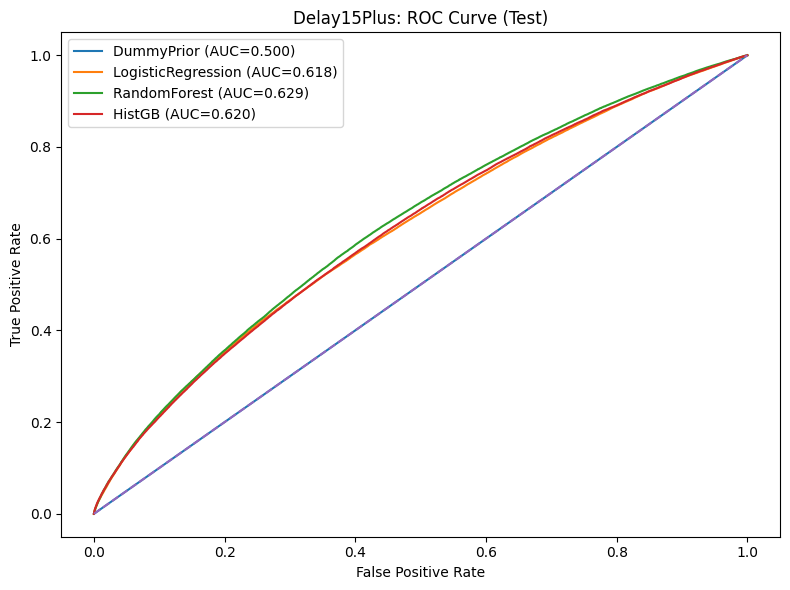

saved: capstone_outputs/figures/delay15plus_pr_test.png


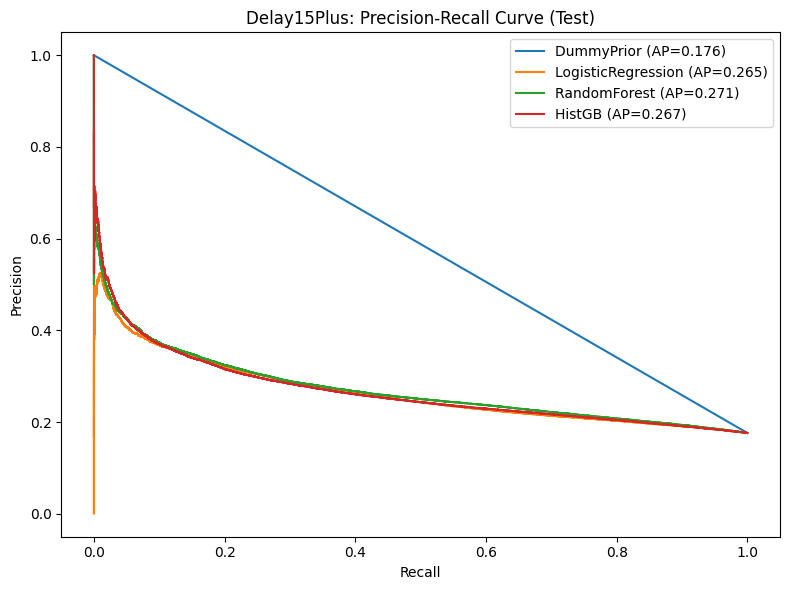


saved: capstone_outputs/tables/delay15plus_randomforest_test_threshold_diagnostics.csv


,threshold,precision,recall,f1
291352,0.202856,0.235168,0.613324,0.339978
291335,0.202851,0.235163,0.613354,0.339977
291351,0.202856,0.235167,0.613324,0.339977
291345,0.202855,0.235165,0.613334,0.339977
291340,0.202853,0.235164,0.613344,0.339976
291386,0.202865,0.235176,0.613263,0.339976
291334,0.202850,0.235162,0.613354,0.339976
291259,0.202824,0.235142,0.613486,0.339976
291253,0.202822,0.235141,0.613496,0.339976
291350,0.202856,0.235166,0.613324,0.339976


[showing first 20 of 50 rows]
saved: capstone_outputs/figures/delay15plus_randomforest_threshold_curve.png


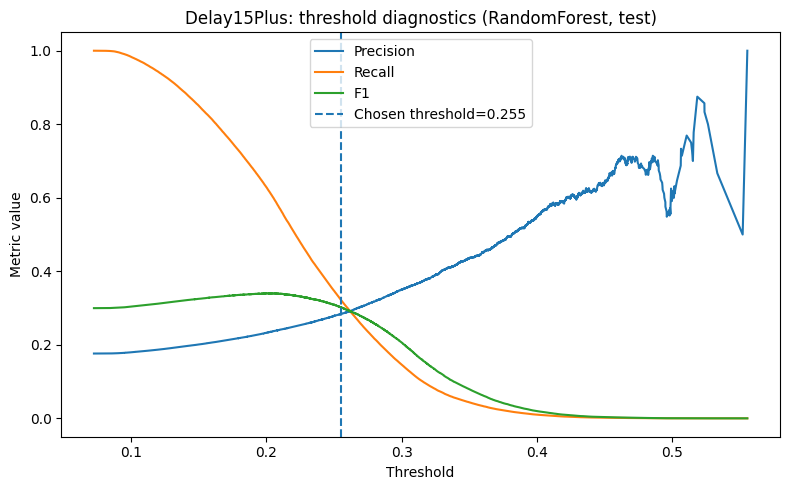

saved: capstone_outputs/figures/delay15plus_randomforest_confusion_matrix.png


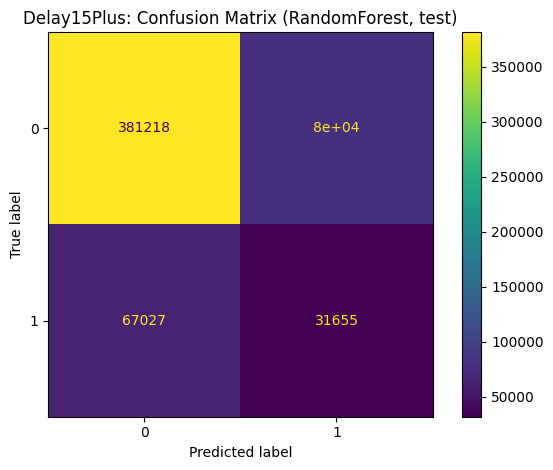


Classification report:
              precision    recall  f1-score   support

           0     0.8505    0.8269    0.8385    461045
           1     0.2839    0.3208    0.3012     98682

    accuracy                         0.7376    559727
   macro avg     0.5672    0.5738    0.5699    559727
weighted avg     0.7506    0.7376    0.7438    559727



In [30]:
# ============================================================
# STANDARD EVALUATION FIGURES
# ============================================================

# ROC
plt.figure(figsize=(8, 6))
for model_name in MODEL_NAMES:
    prob = final_scores[model_name]["test_prob"]
    fpr, tpr, _ = roc_curve(final_y_test, prob)
    auc = roc_auc_score(final_y_test, prob)
    plt.plot(fpr, tpr, label=f"{model_name} (AUC={auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"{TARGET_LABEL}: ROC Curve (Test)")
plt.legend()
save_fig(f"{TARGET_LABEL.lower()}_roc_test.png", show=True)

# PR
plt.figure(figsize=(8, 6))
for model_name in MODEL_NAMES:
    prob = final_scores[model_name]["test_prob"]
    precision, recall, _ = precision_recall_curve(final_y_test, prob)
    ap = average_precision_score(final_y_test, prob)
    plt.plot(recall, precision, label=f"{model_name} (AP={ap:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"{TARGET_LABEL}: Precision-Recall Curve (Test)")
plt.legend()
save_fig(f"{TARGET_LABEL.lower()}_pr_test.png", show=True)

# best model threshold diagnostics on test
best_threshold = float(oof_predictions[best_model_name]["threshold"])
best_test_prob = final_scores[best_model_name]["test_prob"]

prec, rec, thr = precision_recall_curve(final_y_test, best_test_prob)
f1_vals = 2 * prec[:-1] * rec[:-1] / np.clip(prec[:-1] + rec[:-1], 1e-9, None)

threshold_diag_test = pd.DataFrame({
    "threshold": thr,
    "precision": prec[:-1],
    "recall": rec[:-1],
    "f1": f1_vals
}).sort_values("f1", ascending=False)

save_table(threshold_diag_test.head(50), f"{TARGET_LABEL.lower()}_{best_model_name.lower()}_test_threshold_diagnostics.csv", show=True, max_rows=20)

plt.figure(figsize=(8, 5))
plt.plot(thr, prec[:-1], label="Precision")
plt.plot(thr, rec[:-1], label="Recall")
plt.plot(thr, f1_vals, label="F1")
plt.axvline(best_threshold, linestyle="--", label=f"Chosen threshold={best_threshold:.3f}")
plt.xlabel("Threshold")
plt.ylabel("Metric value")
plt.title(f"{TARGET_LABEL}: threshold diagnostics ({best_model_name}, test)")
plt.legend()
save_fig(f"{TARGET_LABEL.lower()}_{best_model_name.lower()}_threshold_curve.png", show=True)

# confusion matrix for best model
best_pred = (best_test_prob >= best_threshold).astype("int8")
cm = confusion_matrix(final_y_test, best_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title(f"{TARGET_LABEL}: Confusion Matrix ({best_model_name}, test)")
save_fig(f"{TARGET_LABEL.lower()}_{best_model_name.lower()}_confusion_matrix.png", show=True)

print("\nClassification report:")
print(classification_report(final_y_test, best_pred, digits=4, zero_division=0))

### Business Objectives Evaluation


saved: capstone_outputs/tables/delay15plus_randomforest_risk_deciles.csv


,risk_decile,flights,observed_rate,mean_predicted_risk
0,1,55973,0.090115,0.103459
1,2,55973,0.106962,0.128728
2,3,55972,0.125634,0.149137
3,4,55973,0.140121,0.168223
4,5,55973,0.153449,0.186731
5,6,55972,0.173783,0.204481
6,7,55973,0.194612,0.222029
7,8,55972,0.210623,0.242866
8,9,55973,0.237436,0.270319
9,10,55973,0.330302,0.323124


saved: capstone_outputs/figures/delay15plus_randomforest_risk_deciles.png


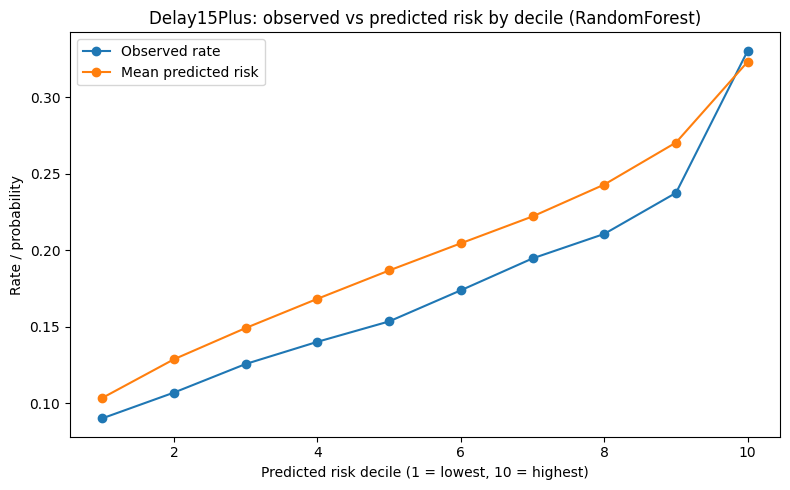


saved: capstone_outputs/tables/delay15plus_randomforest_daily_tracking.csv
saved: capstone_outputs/figures/delay15plus_randomforest_daily_tracking.png


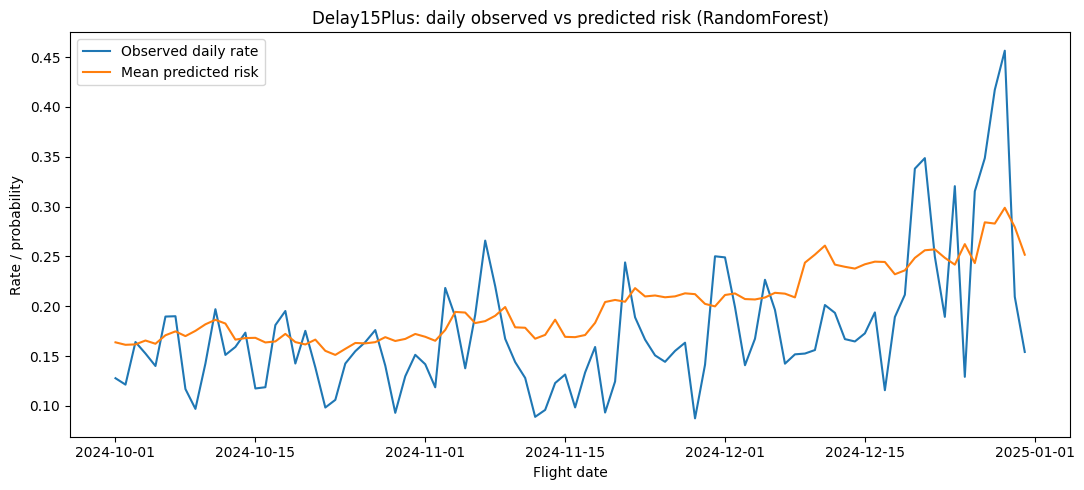


saved: capstone_outputs/tables/delay15plus_randomforest_airport_summary.csv


,ORIGIN,flights,observed_rate,mean_predicted_risk,predicted_positive_rate
1,CLT,54869,0.190399,0.230329,0.304780
8,MIA,26998,0.193940,0.226141,0.293800
3,DFW,77836,0.216070,0.218245,0.308289
5,LAS,48365,0.177897,0.216824,0.240587
7,MCO,37564,0.177643,0.209553,0.192658
2,DEN,77541,0.169575,0.197690,0.167679
9,ORD,70035,0.168573,0.197580,0.170286
4,JFK,31021,0.158151,0.186366,0.156894
0,ATL,86523,0.159391,0.178522,0.146805
6,LAX,48975,0.148076,0.151341,0.029832


saved: capstone_outputs/figures/delay15plus_randomforest_airport_risk.png


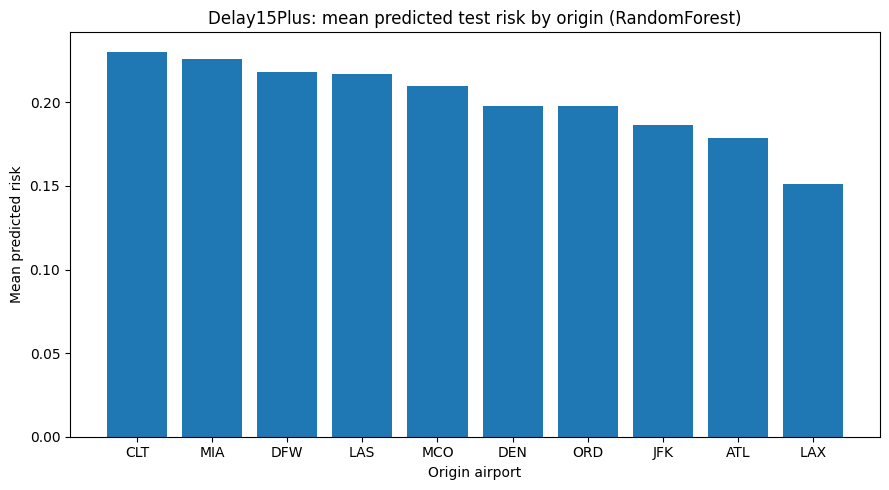


saved: capstone_outputs/tables/delay15plus_randomforest_route_summary_top20.csv


,ROUTE,flights,observed_rate,mean_predicted_risk
463,DFW_BDL,165,0.278788,0.324065
515,DFW_GEG,134,0.358209,0.315334
566,DFW_MSN,263,0.334601,0.312378
1147,ORD_FOD,156,0.262821,0.305586
578,DFW_PBI,276,0.286232,0.304295
981,MCO_PDX,120,0.333333,0.300198
222,CLT_MDW,197,0.335025,0.296407
598,DFW_SAV,226,0.340708,0.295474
480,DFW_CAE,179,0.290503,0.294631
1158,ORD_HSV,213,0.276995,0.292284


saved: capstone_outputs/figures/delay15plus_randomforest_top_routes.png


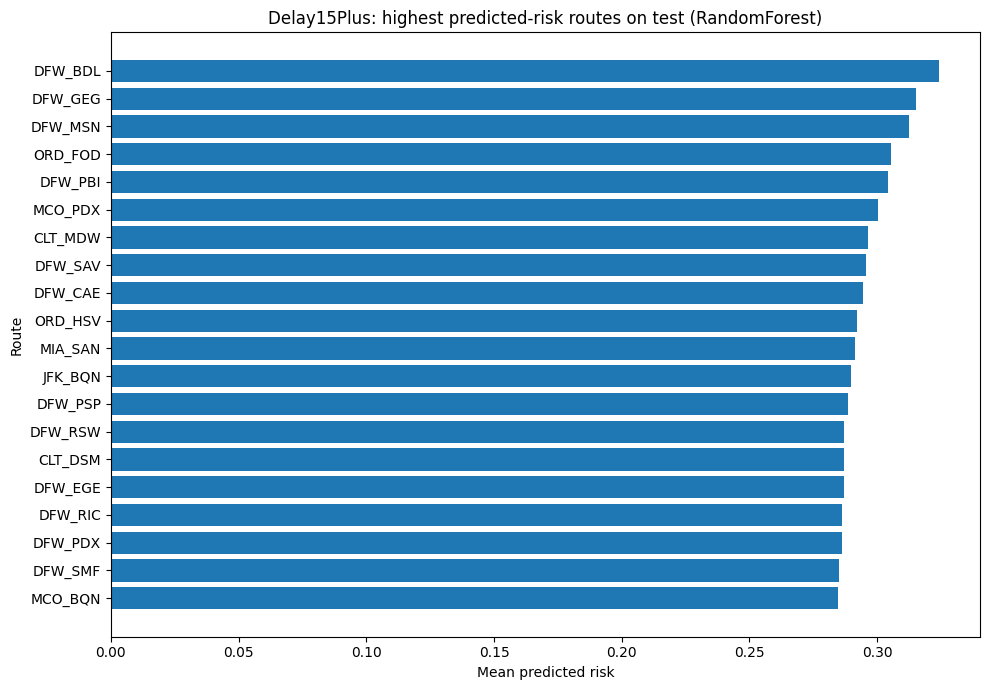

In [32]:
# ============================================================
# BUSINESS-CONTEXT EVALUATION
# ============================================================

best_test_prob = final_scores[best_model_name]["test_prob"]
best_threshold = float(oof_predictions[best_model_name]["threshold"])
best_pred = (best_test_prob >= best_threshold).astype("int8")

test_scored = meta_test.copy()
test_scored["actual"] = final_y_test.values
test_scored["pred_prob"] = best_test_prob
test_scored["pred_class"] = best_pred

# -----------------------------
# risk deciles
# -----------------------------
test_scored["risk_decile"] = pd.qcut(
    test_scored["pred_prob"].rank(method="first"),
    10,
    labels=False
) + 1

decile_summary = (
    test_scored.groupby("risk_decile", as_index=False)
    .agg(
        flights=("actual", "size"),
        observed_rate=("actual", "mean"),
        mean_predicted_risk=("pred_prob", "mean")
    )
    .sort_values("risk_decile")
)

save_table(decile_summary, f"{TARGET_LABEL.lower()}_{best_model_name.lower()}_risk_deciles.csv", show=True)

plt.figure(figsize=(8, 5))
plt.plot(decile_summary["risk_decile"], decile_summary["observed_rate"], marker="o", label="Observed rate")
plt.plot(decile_summary["risk_decile"], decile_summary["mean_predicted_risk"], marker="o", label="Mean predicted risk")
plt.xlabel("Predicted risk decile (1 = lowest, 10 = highest)")
plt.ylabel("Rate / probability")
plt.title(f"{TARGET_LABEL}: observed vs predicted risk by decile ({best_model_name})")
plt.legend()
save_fig(f"{TARGET_LABEL.lower()}_{best_model_name.lower()}_risk_deciles.png", show=True)

# -----------------------------
# daily tracking
# -----------------------------
daily_tracking = (
    test_scored.groupby("FLIGHT_DATE", as_index=False)
    .agg(
        flights=("actual", "size"),
        observed_rate=("actual", "mean"),
        mean_predicted_risk=("pred_prob", "mean")
    )
)

save_table(daily_tracking, f"{TARGET_LABEL.lower()}_{best_model_name.lower()}_daily_tracking.csv", show=False)

plt.figure(figsize=(11, 5))
plt.plot(daily_tracking["FLIGHT_DATE"], daily_tracking["observed_rate"], label="Observed daily rate")
plt.plot(daily_tracking["FLIGHT_DATE"], daily_tracking["mean_predicted_risk"], label="Mean predicted risk")
plt.xlabel("Flight date")
plt.ylabel("Rate / probability")
plt.title(f"{TARGET_LABEL}: daily observed vs predicted risk ({best_model_name})")
plt.legend()
save_fig(f"{TARGET_LABEL.lower()}_{best_model_name.lower()}_daily_tracking.png", show=True)

# -----------------------------
# airport summary
# -----------------------------
if "ORIGIN" in test_scored.columns:
    airport_summary = (
        test_scored.groupby("ORIGIN", as_index=False)
        .agg(
            flights=("actual", "size"),
            observed_rate=("actual", "mean"),
            mean_predicted_risk=("pred_prob", "mean"),
            predicted_positive_rate=("pred_class", "mean")
        )
        .sort_values("mean_predicted_risk", ascending=False)
    )

    save_table(airport_summary, f"{TARGET_LABEL.lower()}_{best_model_name.lower()}_airport_summary.csv", show=True)

    plt.figure(figsize=(9, 5))
    plt.bar(airport_summary["ORIGIN"], airport_summary["mean_predicted_risk"])
    plt.xlabel("Origin airport")
    plt.ylabel("Mean predicted risk")
    plt.title(f"{TARGET_LABEL}: mean predicted test risk by origin ({best_model_name})")
    save_fig(f"{TARGET_LABEL.lower()}_{best_model_name.lower()}_airport_risk.png", show=True)

# -----------------------------
# highest-risk routes with volume floor
# -----------------------------
if "ROUTE" in test_scored.columns:
    route_summary = (
        test_scored.groupby("ROUTE", as_index=False)
        .agg(
            flights=("actual", "size"),
            observed_rate=("actual", "mean"),
            mean_predicted_risk=("pred_prob", "mean")
        )
    )

    route_summary = route_summary.loc[route_summary["flights"] >= 100].copy()
    route_summary = route_summary.sort_values("mean_predicted_risk", ascending=False).head(20)

    save_table(route_summary, f"{TARGET_LABEL.lower()}_{best_model_name.lower()}_route_summary_top20.csv", show=True)

    plt.figure(figsize=(10, 7))
    plt.barh(route_summary["ROUTE"][::-1], route_summary["mean_predicted_risk"][::-1])
    plt.xlabel("Mean predicted risk")
    plt.ylabel("Route")
    plt.title(f"{TARGET_LABEL}: highest predicted-risk routes on test ({best_model_name})")
    save_fig(f"{TARGET_LABEL.lower()}_{best_model_name.lower()}_top_routes.png", show=True)

### Feature Importances



saved: capstone_outputs/tables/delay15plus_randomforest_top_features.csv


,feature,importance
72,TE_CARRIER_ROUTE,0.088160
58,DOY_SIN,0.083975
59,DOY_COS,0.075206
28,origin_origin_delay_rate_lag1,0.074666
41,carrier_route_carrier_route_delay_rate_roll30,0.071753
30,origin_origin_cancel_rate_lag1,0.039232
48,CARRIER_ROUTE_DELAY_RATE_EXPANDING,0.038463
29,origin_origin_delay_rate_roll30,0.036615
35,route_route_delay_rate_roll30,0.033923
71,TE_ROUTE,0.026911


saved: capstone_outputs/figures/delay15plus_randomforest_top_features.png


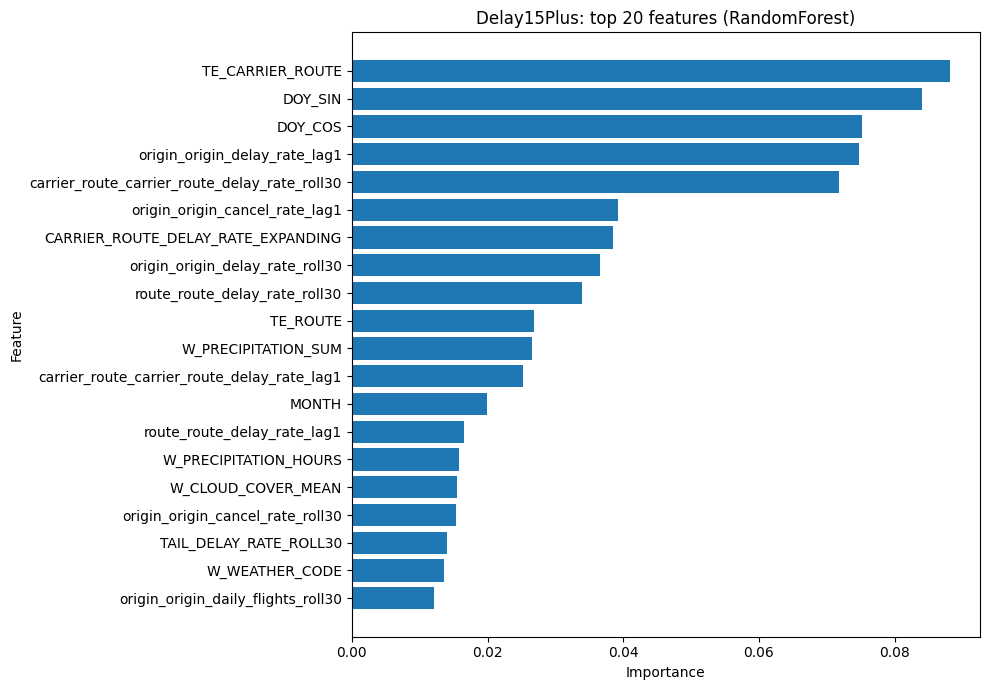

In [34]:
# ============================================================
# FEATURE IMPORTANCE / EXPLANATION
# ============================================================

best_pipe = final_models[best_model_name]

# access fitted estimator inside the pipeline where relevant
if isinstance(best_pipe, Pipeline) and "model" in best_pipe.named_steps:
    best_estimator = best_pipe.named_steps["model"]
else:
    best_estimator = best_pipe

feat_imp = None

if hasattr(best_estimator, "coef_"):
    feat_imp = pd.DataFrame({
        "feature": feature_names,
        "importance": np.abs(best_estimator.coef_[0])
    }).sort_values("importance", ascending=False)

elif hasattr(best_estimator, "feature_importances_"):
    feat_imp = pd.DataFrame({
        "feature": feature_names,
        "importance": best_estimator.feature_importances_
    }).sort_values("importance", ascending=False)

else:
    # permutation importance fallback
    sample_n = min(len(X_test_final), 20_000)
    X_pi = X_test_final.iloc[:sample_n].copy()
    y_pi = final_y_test.iloc[:sample_n].copy()

    t0 = time.time()
    pi = permutation_importance(
        best_pipe,
        X_pi,
        y_pi,
        n_repeats=5,
        random_state=RANDOM_STATE,
        scoring="average_precision",
        n_jobs=-1
    )
    print("permutation importance sec:", round(time.time() - t0, 2))

    feat_imp = pd.DataFrame({
        "feature": feature_names,
        "importance": pi.importances_mean
    }).sort_values("importance", ascending=False)

top_features = feat_imp.head(20).copy()
save_table(top_features, f"{TARGET_LABEL.lower()}_{best_model_name.lower()}_top_features.csv", show=True)

plt.figure(figsize=(10, 7))
plt.barh(top_features["feature"][::-1], top_features["importance"][::-1])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title(f"{TARGET_LABEL}: top 20 features ({best_model_name})")
save_fig(f"{TARGET_LABEL.lower()}_{best_model_name.lower()}_top_features.png", show=True)

### Final Outputs

In [36]:
# ============================================================
# ARTICLE-READY SUMMARY TABLES
# ============================================================

# final test comparison only
article_test_table = (
    final_metrics[final_metrics["split"] == "test"]
    .copy()
    .sort_values("pr_auc", ascending=False)
    .reset_index(drop=True)
)

save_table(article_test_table, f"{TARGET_LABEL.lower()}_article_test_comparison_table.csv", show=True)

display(style_metric_table(
    article_test_table,
    metric_cols=["accuracy", "balanced_accuracy", "precision", "recall", "f1", "roc_auc", "pr_auc"]
))

# threshold summary
article_threshold_table = threshold_table.merge(
    cv_model_summary[["model", "best_f1_threshold", "oof_f1_at_best_f1", "oof_pr_auc", "oof_roc_auc"]],
    on="model",
    how="left"
).sort_values("oof_pr_auc", ascending=False)

save_table(article_threshold_table, f"{TARGET_LABEL.lower()}_article_threshold_table.csv", show=True)


saved: capstone_outputs/tables/delay15plus_article_test_comparison_table.csv


,model,split,threshold,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,pr_auc,predicted_positive_rate,actual_positive_rate
0,RandomForest,test,0.2554,0.7376,0.5738,0.2839,0.3208,0.3012,0.6289,0.2710,0.1992,0.1763
1,HistGB,test,0.2128,0.5888,0.5844,0.2322,0.5776,0.3312,0.6198,0.2669,0.4385,0.1763
2,LogisticRegression,test,0.2179,0.4791,0.5732,0.2119,0.7187,0.3273,0.6182,0.2645,0.5981,0.1763
3,DummyPrior,test,0.2419,0.1763,0.5000,0.1763,1.0000,0.2998,0.5000,0.1763,1.0000,0.1763


,model,split,threshold,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,pr_auc,predicted_positive_rate,actual_positive_rate
0,RandomForest,test,0.2554,0.7376,0.5738,0.2839,0.3208,0.3012,0.6289,0.2710,0.1992,0.1763
1,HistGB,test,0.2128,0.5888,0.5844,0.2322,0.5776,0.3312,0.6198,0.2669,0.4385,0.1763
2,LogisticRegression,test,0.2179,0.4791,0.5732,0.2119,0.7187,0.3273,0.6182,0.2645,0.5981,0.1763
3,DummyPrior,test,0.2419,0.1763,0.5000,0.1763,1.0000,0.2998,0.5000,0.1763,1.0000,0.1763



saved: capstone_outputs/tables/delay15plus_article_threshold_table.csv


,model,selected_threshold,fit_sec_final,best_f1_threshold,oof_f1_at_best_f1,oof_pr_auc,oof_roc_auc
2,RandomForest,0.2554,29.73,0.2554,0.4757,0.4210,0.6578
3,HistGB,0.2128,16.90,0.2128,0.4665,0.4005,0.6405
1,LogisticRegression,0.2179,15.35,0.2179,0.4622,0.3805,0.6290
0,DummyPrior,0.2419,0.01,0.2419,0.4344,0.2564,0.4502


### Investigative Modeling Diagnostics

In [ ]:
# from pathlib import Path
# import json
# import time
# import requests
# import gc
# import warnings
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# from IPython.display import display

# from scipy import sparse

# from sklearn.base import clone
# from sklearn.compose import ColumnTransformer
# from sklearn.dummy import DummyClassifier
# from sklearn.impute import SimpleImputer
# from sklearn.linear_model import LogisticRegression
# from sklearn.metrics import (
#     accuracy_score,
#     average_precision_score,
#     balanced_accuracy_score,
#     classification_report,
#     confusion_matrix,
#     ConfusionMatrixDisplay,
#     f1_score,
#     precision_recall_curve,
#     precision_score,
#     recall_score,
#     roc_auc_score,
#     roc_curve
# )
# from sklearn.model_selection import cross_validate, cross_val_predict
# from sklearn.pipeline import Pipeline
# from sklearn.preprocessing import OneHotEncoder, StandardScaler
# from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier

# warnings.filterwarnings("ignore")
# RANDOM_STATE = 42


# def save_table(df, name, show=True, max_rows=20):
#     path = TAB_DIR / name
#     df.to_csv(path, index=False)
#     print(f"\nsaved: {path}")

#     if show:
#         if len(df) <= max_rows:
#             display(df)
#         else:
#             display(df.head(max_rows))
#             print(f"[showing first {max_rows} of {len(df)} rows]")

# def save_fig(name, show=True):
#     path = FIG_DIR / name
#     plt.tight_layout()
#     plt.savefig(path, dpi=170, bbox_inches="tight")
#     print(f"saved: {path}")

#     if show:
#         plt.show()
#     else:
#         plt.close()

In [ ]:

# DATA_PATH = Path("/content/BTS_2024_top10_origin_combined.parquet")
# OUT_DIR = Path("/content/capstone_outputs")
# FIG_DIR = OUT_DIR / "figures"
# TAB_DIR = OUT_DIR / "tables"
# CACHE_DIR = OUT_DIR / "cache"

# MODEL_DF_PATH = OUT_DIR / "modeling_frame.parquet"

# df = pd.read_parquet(MODEL_DF_PATH)
# print(df.shape)

In [ ]:
# print("shape:", df.shape)
# print("\nfirst 120 columns:")
# print(df.columns.tolist()[:120])

# print("\ndtypes summary:")
# print(df.dtypes.astype(str).value_counts())

# print("\nkey target/date checks:")
# for c in ["FLIGHT_DATE", "TARGET_DELAY15", "TARGET_CANCELLED"]:
#     print(c, "exists?" , c in df.columns)

# if "FLIGHT_DATE" in df.columns:
#     df["FLIGHT_DATE"] = pd.to_datetime(df["FLIGHT_DATE"], errors="coerce")
#     print("date min:", df["FLIGHT_DATE"].min())
#     print("date max:", df["FLIGHT_DATE"].max())
#     print("n unique dates:", df["FLIGHT_DATE"].nunique())

# for tgt in ["TARGET_DELAY15", "TARGET_CANCELLED"]:
#     if tgt in df.columns:
#         s = pd.to_numeric(df[tgt], errors="coerce")
#         print(f"\n{tgt}:")
#         print("  non-null:", s.notna().sum())
#         print("  missing :", s.isna().sum())
#         print("  mean    :", float(s.mean()))
#         print("  value counts:")
#         print(s.value_counts(dropna=False).sort_index())

In [ ]:
# suspect_patterns = [
#     "DEP_TIME", "DEP_DELAY", "ARR_TIME", "ARR_DELAY", "ARR_DEL15",
#     "TAXI_OUT", "TAXI_IN", "ACTUAL", "AIR_TIME",
#     "CARRIER_DELAY", "WEATHER_DELAY", "NAS_DELAY", "SECURITY_DELAY",
#     "LATE_AIRCRAFT_DELAY", "CANCELLATION_CODE",
#     "WHEELS_OFF", "WHEELS_ON", "CRS_ELAPSED_TIME"
# ]

# suspects = []
# for col in df.columns:
#     u = col.upper()
#     if any(p in u for p in suspect_patterns):
#         suspects.append(col)

# print("suspicious columns still present:")
# for c in sorted(suspects):
#     print(c)

In [ ]:
# mem_mb = df.memory_usage(deep=True).sum() / (1024**2)
# print(f"total memory MB: {mem_mb:,.2f}")

# summary = pd.DataFrame({
#     "dtype": df.dtypes.astype(str),
#     "missing_pct": df.isna().mean() * 100,
#     "nunique": df.nunique(dropna=False)
# }).sort_values(["missing_pct", "nunique"], ascending=[False, False])

# print("\nTop 40 by missingness:")
# print(summary.head(40))

# obj_cat_cols = df.select_dtypes(include=["object", "category", "string"]).columns.tolist()
# card = pd.DataFrame({
#     "column": obj_cat_cols,
#     "nunique": [df[c].nunique(dropna=False) for c in obj_cat_cols],
#     "missing_pct": [df[c].isna().mean() * 100 for c in obj_cat_cols]
# }).sort_values("nunique", ascending=False)

# print("\nCategorical columns by cardinality:")
# print(card.head(50))

In [ ]:
# df["FLIGHT_DATE"] = pd.to_datetime(df["FLIGHT_DATE"], errors="coerce")
# df = df.sort_values("FLIGHT_DATE").copy()

# train_end = "2024-09-30"
# test_start = "2024-10-01"

# train_df = df[df["FLIGHT_DATE"] <= train_end].copy()
# test_df  = df[df["FLIGHT_DATE"] >= test_start].copy()

# print("train shape:", train_df.shape)
# print("test shape :", test_df.shape)

# for tgt in ["TARGET_DELAY15", "TARGET_CANCELLED"]:
#     if tgt in df.columns:
#         print(f"\n{tgt} rates")
#         print("train:", pd.to_numeric(train_df[tgt], errors="coerce").mean())
#         print("test :", pd.to_numeric(test_df[tgt], errors="coerce").mean())

# monthly = (
#     df.assign(month=df["FLIGHT_DATE"].dt.to_period("M").astype(str))
#       .groupby("month", observed=True)
#       .agg(
#           n=("FLIGHT_DATE", "size"),
#           delay_rate=("TARGET_DELAY15", "mean"),
#           cancel_rate=("TARGET_CANCELLED", "mean")
#       )
#       .reset_index()
# )
# print("\nMonthly rates:")
# print(monthly)

In [ ]:
# num_cols = df.select_dtypes(include=[np.number, "bool"]).columns.tolist()
# num_cols = [c for c in num_cols if c not in ["TARGET_DELAY15", "TARGET_CANCELLED"]]

# num_summary = pd.DataFrame({
#     "column": num_cols,
#     "missing_pct": [df[c].isna().mean() * 100 for c in num_cols],
#     "nunique": [df[c].nunique(dropna=False) for c in num_cols],
#     "std": [pd.to_numeric(df[c], errors="coerce").std() for c in num_cols]
# }).sort_values(["std", "missing_pct"], ascending=[True, False])

# print("Likely constant / near-constant numeric columns:")
# print(num_summary.head(40))

# print("\nHighest-variance numeric columns:")
# print(num_summary.sort_values("std", ascending=False).head(40))

In [ ]:
# sample_num_cols = [c for c in num_cols if df[c].notna().sum() > 1000]
# sample_num_cols = sample_num_cols[:120]  # keep this manageable

# corr = df[sample_num_cols].corr(numeric_only=True).abs()
# upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

# pairs = (
#     upper.stack()
#          .reset_index()
#          .rename(columns={"level_0": "feature_1", "level_1": "feature_2", 0: "abs_corr"})
#          .sort_values("abs_corr", ascending=False)
# )

# print("Top highly correlated numeric pairs:")
# print(pairs.head(50))

In [ ]:
# from sklearn.model_selection import train_test_split

# import pandas as pd
# import numpy as np

# tmp = train_df.copy()
# y = pd.to_numeric(tmp["TARGET_DELAY15"], errors="coerce")
# mask = y.notna()
# tmp = tmp.loc[mask].copy()
# y = y.loc[mask].astype("int8")

# drop_cols = [
#     "FLIGHT_DATE", "TARGET_DELAY15", "TARGET_CANCELLED",
#     "DEP_TIME", "DEP_DELAY", "DEP_DEL15", "CANCELLED",
#     "TAXI_OUT", "TAXI_IN", "ARR_TIME", "ARR_DELAY",
#     "ARR_DEL15", "ACTUAL_ELAPSED_TIME", "AIR_TIME", "CARRIER_DELAY",
#     "WEATHER_DELAY", "NAS_DELAY", "SECURITY_DELAY", "LATE_AIRCRAFT_DELAY",
#     "CANCELLATION_CODE", "ACTUAL_DEP_HOUR",
#     "TAIL_PREV_ARR_DELAY_PRIOR", "TAIL_PREV_DEP_DELAY_PRIOR",
#     "TAIL_PREV_CANCELLED_PRIOR"
# ]
# drop_cols = [c for c in drop_cols if c in tmp.columns]

# X = tmp.drop(columns=drop_cols, errors="ignore").copy()

# n = min(len(X), 200_000)
# X = X.iloc[:n].copy()
# y = y.iloc[:n].copy()

# # Make pandas extension dtypes safe for get_dummies
# for c in X.columns:
#     dt = X[c].dtype

#     # nullable boolean -> regular bool or int8
#     if str(dt) == "boolean":
#         X[c] = X[c].fillna(False).astype("bool")

#     # nullable integer -> float32 or int32 after fill
#     elif str(dt) == "Int64":
#         X[c] = X[c].astype("float32")

#     # pandas string dtype -> object
#     elif str(dt) == "string":
#         X[c] = X[c].astype("object")

#     # category is fine, but object is also safe
#     elif str(dt) == "category":
#         X[c] = X[c].astype("object")

# X_dum = pd.get_dummies(X, drop_first=True, sparse=True, dummy_na=False)

# print("raw X shape:", X.shape)
# print("dummy X shape:", X_dum.shape)
# print("dummy memory MB (pandas estimate):", X_dum.memory_usage(deep=True).sum() / (1024**2))

# nonzero = 0
# for c in X_dum.columns[:min(500, X_dum.shape[1])]:
#     s = X_dum[c]
#     try:
#         nonzero += s.sparse.npoints
#     except Exception:
#         nonzero += (s != 0).sum()

# print("sampled first 500 cols nonzero count:", nonzero)
# print("\nproblem dtypes after coercion:")
# print(X.dtypes.astype(str).value_counts())

In [ ]:
# import gc
# import time
# import numpy as np
# import pandas as pd

# from sklearn.compose import ColumnTransformer
# from sklearn.pipeline import Pipeline
# from sklearn.impute import SimpleImputer
# from sklearn.preprocessing import OrdinalEncoder, StandardScaler
# from sklearn.linear_model import LogisticRegression
# from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
# from sklearn.metrics import (
#     roc_auc_score,
#     average_precision_score,
#     precision_score,
#     recall_score,
#     f1_score
# )

# # -----------------------------
# # 1) Build lean train/test sets
# # -----------------------------
# tmp = df.sort_values("FLIGHT_DATE").copy()
# tmp = tmp[tmp["TARGET_DELAY15"].notna()].copy()

# train_sub = tmp[tmp["FLIGHT_DATE"] <= train_end].head(120_000).copy()
# test_sub  = tmp[tmp["FLIGHT_DATE"] >= test_start].head(50_000).copy()

# # -----------------------------
# # 2) Drop leakage + high-risk columns
# # -----------------------------
# drop_cols = [
#     # IDs / targets / date
#     "FLIGHT_DATE", "TARGET_DELAY15", "TARGET_CANCELLED",

#     # direct leakage / post-event
#     "DEP_TIME", "DEP_DELAY", "DEP_DEL15", "CANCELLED",
#     "TAXI_OUT", "TAXI_IN", "ARR_TIME", "ARR_DELAY", "ARR_DEL15",
#     "ACTUAL_ELAPSED_TIME", "AIR_TIME",
#     "CARRIER_DELAY", "WEATHER_DELAY", "NAS_DELAY",
#     "SECURITY_DELAY", "LATE_AIRCRAFT_DELAY",
#     "ACTUAL_DEP_HOUR",

#     # prior-flight features that may not be operationally available or are too sparse/noisy for this quick diagnostic
#     "TAIL_PREV_ARR_DELAY_PRIOR", "TAIL_PREV_DEP_DELAY_PRIOR", "TAIL_PREV_CANCELLED_PRIOR",
#     "PREV_ORIGIN_DEST",

#     # very high-cardinality identifiers / route keys for this quick benchmark
#     "TAIL_NUM", "CARRIER_ROUTE", "ROUTE",
#     "ORIGIN_CITY_NAME", "DEST_CITY_NAME"
# ]
# drop_cols = [c for c in drop_cols if c in train_sub.columns]

# X_train = train_sub.drop(columns=drop_cols, errors="ignore").copy()
# y_train = pd.to_numeric(train_sub["TARGET_DELAY15"], errors="coerce").astype("int8")

# X_test = test_sub.drop(columns=drop_cols, errors="ignore").copy()
# y_test = pd.to_numeric(test_sub["TARGET_DELAY15"], errors="coerce").astype("int8")

# del train_sub, test_sub, tmp
# gc.collect()

# # -----------------------------
# # 3) Make sklearn-safe and compact
# # -----------------------------
# def make_sklearn_safe(frame):
#     out = frame.copy()

#     for c in out.columns:
#         dt = str(out[c].dtype)

#         if dt == "boolean":
#             out[c] = out[c].astype("float32")
#         elif dt == "Int64":
#             out[c] = out[c].astype("float32")
#         elif dt == "string":
#             out[c] = out[c].astype("object")
#         elif dt == "category":
#             out[c] = out[c].astype("object")

#     out = out.replace({pd.NA: np.nan})
#     return out

# X_train = make_sklearn_safe(X_train)
# X_test = make_sklearn_safe(X_test)

# # Downcast numerics to reduce RAM
# num_like = X_train.select_dtypes(include=[np.number, "bool"]).columns.tolist()
# for c in num_like:
#     X_train[c] = pd.to_numeric(X_train[c], errors="coerce").astype("float32")
#     X_test[c] = pd.to_numeric(X_test[c], errors="coerce").astype("float32")

# num_cols = X_train.select_dtypes(include=[np.number, "bool"]).columns.tolist()
# cat_cols = [c for c in X_train.columns if c not in num_cols]

# print("X_train shape:", X_train.shape)
# print("X_test shape :", X_test.shape)
# print("numeric cols :", len(num_cols))
# print("categorical cols:", len(cat_cols))
# print("X_train memory MB:", round(X_train.memory_usage(deep=True).sum() / (1024**2), 2))

# # -----------------------------
# # 4) Cheap preprocessing
# # -----------------------------
# # Ordinal encoding is not ideal as a final representation for all models,
# # but it is the most efficient way to benchmark signal quality and runtime.
# pre = ColumnTransformer(
#     transformers=[
#         ("num", Pipeline([
#             ("imp", SimpleImputer(strategy="median")),
#             ("scaler", StandardScaler())
#         ]), num_cols),
#         ("cat", Pipeline([
#             ("imp", SimpleImputer(strategy="most_frequent")),
#             ("ord", OrdinalEncoder(
#                 handle_unknown="use_encoded_value",
#                 unknown_value=-1,
#                 encoded_missing_value=-2
#             ))
#         ]), cat_cols),
#     ],
#     remainder="drop"
# )

# # -----------------------------
# # 5) Lean model configs
# # -----------------------------
# models = {
#     "logreg": LogisticRegression(
#         max_iter=250,
#         solver="saga",
#         n_jobs=-1,
#         class_weight=None,
#         random_state=42
#     ),
#     "rf": RandomForestClassifier(
#         n_estimators=80,
#         max_depth=10,
#         min_samples_leaf=25,
#         max_features="sqrt",
#         n_jobs=-1,
#         random_state=42
#     ),
#     "hgb": HistGradientBoostingClassifier(
#         max_depth=6,
#         max_iter=120,
#         learning_rate=0.06,
#         min_samples_leaf=40,
#         random_state=42
#     )
# }

# benchmark_results = {}
# best_name = None
# best_proba = None
# best_auc = -np.inf
# best_pipe = None

# for name, model in models.items():
#     print(f"\n--- {name} ---")
#     pipe = Pipeline([
#         ("pre", pre),
#         ("model", model)
#     ])

#     t0 = time.time()
#     pipe.fit(X_train, y_train)
#     fit_sec = time.time() - t0

#     if hasattr(pipe, "predict_proba"):
#         proba = pipe.predict_proba(X_test)[:, 1]
#     else:
#         proba = pipe.decision_function(X_test)

#     pred = (proba >= 0.5).astype("int8")

#     result = {
#         "fit_sec": round(fit_sec, 2),
#         "roc_auc": round(roc_auc_score(y_test, proba), 4),
#         "pr_auc": round(average_precision_score(y_test, proba), 4),
#         "precision_05": round(precision_score(y_test, pred, zero_division=0), 4),
#         "recall_05": round(recall_score(y_test, pred, zero_division=0), 4),
#         "f1_05": round(f1_score(y_test, pred, zero_division=0), 4),
#     }
#     benchmark_results[name] = result
#     print(result)

#     if result["roc_auc"] > best_auc:
#         best_auc = result["roc_auc"]
#         best_name = name
#         best_proba = proba.copy()
#         best_pipe = pipe

#     if name != best_name:
#         del pipe, proba, pred
#         gc.collect()

# print("\nBest model by ROC-AUC:", best_name)
# print("Benchmark results:")
# print(pd.DataFrame(benchmark_results).T)

# # keep these for the threshold diagnostic
# proba = best_proba
# pipe = best_pipe

In [ ]:
# from sklearn.metrics import precision_recall_curve

# prec, rec, thr = precision_recall_curve(y_test, proba)
# f1 = 2 * prec[:-1] * rec[:-1] / np.clip(prec[:-1] + rec[:-1], 1e-9, None)

# diag = pd.DataFrame({
#     "threshold": thr,
#     "precision": prec[:-1],
#     "recall": rec[:-1],
#     "f1": f1
# }).sort_values("f1", ascending=False)

# print(diag.head(20))

# print("\nProbability summary:")
# print(pd.Series(proba).describe(percentiles=[.01, .05, .1, .25, .5, .75, .9, .95, .99]))